# ***PROJECT 1***

## **1. DEFINING THE PROBLEM**
****

### **TASK/PROBLEM** - **HOW DO PLAYER SPEED, POSITIONING, AND TEAM FORMATION IMPACT THE LIKELIHOOD OF A SUCCESSFUL PLAY IN NFL (NATIONAL FOOTBALL ASSOCIATION) GAMES?**

***Why is this interesting?***

Mainly because I'm very passionate about sports and I've been playing soccer since my childhood. Sports Analytics is something that has always kept me intrigued to explore into but I never had the chance to.

But now you would ask me why football and not soccer, well I did my research to find good and up-to-date datasets for soccer but to my luck I couldn't find any. However, I found out that NFL does a Big Data Bowl competition every year for enthusiastic data scientists/analysts to work on. They have exhaustive and accurate data from 2023-2025, to perform certain tasks which they ask to submit for the competition.

For 2025, it just opened up and I could not have asked for a better timing!

***Why is this important?***

**Relevance** - A lot of sports teams do analytics and so do NFL teams. Teams and analysts rely heavily on player-tracking analytics to optimize play-calling, defensive coverage, and offensive formations. Understanding these strategies gives direct insights into beetter decision-making in professional sports.

**Novelty** - Sports analytics is a growing field, and the NFL Big Data Bowl is one of the very few publicly and up-to-date available datasets at this level of detail. Working on such a project would give exposure to actual data that professionals also use for team analytics.

**Wider Use** - Although this data is specific to football, the same methods can be applied to soccer, basketball or any such team sports.

## **2. POPULATION**
****

The population that I wish to study are all NFL participating players in the 2023-2024 season. Although the data exists till 2025, I would like to limit it to all games until the end of 2024 season which is around January/February of 2024. If possible, I will extend to the 2024-2025 season.

## **3. VARIABLES**
****

**Independent Variables -**  
`s`(Speed), `a`(Acceleration), `x`(x-coordinate), `y`(y-coordinate), `o`(Orientation), `dir`(Direction), `offense_formation`(Formation), `down`(Down), `yards_to_go`(yards to go)

**Dependent Variables -**  
`pass_result` (Categorical value suggesting C: Complete pass, I: Incomplete pass, S: Quarterback sack, IN: Intercepted pass, R: Scramble)

**Confounding Variables -**  
Extraneous variable / external factor that may affect the relationships between dependent and independent variables. May not be the focus of the study but can impact the results by influencing the IV-DV relationship. An additional factor that is not controlled for but could potentially influence the outcomes.

`game_time_eastern`(time of the day the game was played), `home_team_abbr`(whether the team was playing at Home stadium or not), `game_clock`(what was the game clock time when the play was made), `pre_snap_home_score` and `pre_snap_visitor_score` (scores of the team at the instance that the play was made)

I will try to include them in the analysis if I can come up with a valid classification for the data in those variables. For example: `game_clock` and `pre_snap_home_score` and `pre_snap_visitor_score` can be used to indicate the pressure on the players to make a successful play. The closer the game clock to the end of the time which is 60 minutes, and the difference in scores, the more pressure on the players and less likely for the pass to be successful.

## **4. HYPOTHESIS**
****

**Null Hypothesis (H0):**  
Player speed, positioning, and formation do not significantly affect the probability of a successful play.

**Alternative Hypothesis (H1):**  
Higher player speed, optimal positioning, and certain formations increase the likelihood of a successful play.

## **5. DATA COLLECTION**
****

**Dataset Source:** Kaggle NFL Big Data Bowl 2026: Analytics  
**Link:** https://www.kaggle.com/competitions/nfl-big-data-bowl-2026-analytics/data

**Files:**  
- `input_2023_w[01-18].csv` – The input data contains tracking data before the pass is thrown.  
- `output_2023_w[01-18].csv` – The output data contains tracking data after the pass is thrown.
- `supplementary_data.csv` – Contextual info about the game like: GameID, teams, quarter, time  

**Method:**  
- Download CSV files and upload to Colab  
- Merge certain columns of the datasets to obtain the final dataset to be worked  
- Ensure representative coverage by keeping all games/plays

This dataset is particularly interesting because it has such minute data of an entire 60 minute game and making an analysis of the success of a pass is something that is still being refined and very sought after by many sports teams and associations. In soccer you can observe a version of this called 'xG' which is the likelihood of a player scoring a goal from a certain position of the field and lots of other dependent things.

## **6. IMPORT THE DATA AND FIRST 5 ENTRIES OF THE DATA**
****

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Importing the data from my Google Drive
supplementary_df=pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/supplementary_data.csv')
input_w01=pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/train/input_2023_w01.csv')
output_w01=pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/train/output_2023_w01.csv')

In [ ]:
# Attributes of the datasets and some basic understandings of the variables
supplementary_df.info() # Info about the Supplementary_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18009 entries, 0 to 18008
Data columns (total 41 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   game_id                                18009 non-null  int64  
 1   season                                 18009 non-null  int64  
 2   week                                   18009 non-null  int64  
 3   game_date                              18009 non-null  object 
 4   game_time_eastern                      18009 non-null  object 
 5   home_team_abbr                         18009 non-null  object 
 6   visitor_team_abbr                      18009 non-null  object 
 7   play_id                                18009 non-null  int64  
 8   play_description                       18009 non-null  object 
 9   quarter                                18009 non-null  int64  
 10  game_clock                             18009 non-null  object 
 11  do

In [ ]:
input_w01.info() # Info about the input_w01 dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285714 entries, 0 to 285713
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   game_id                   285714 non-null  int64  
 1   play_id                   285714 non-null  int64  
 2   player_to_predict         285714 non-null  bool   
 3   nfl_id                    285714 non-null  int64  
 4   frame_id                  285714 non-null  int64  
 5   play_direction            285714 non-null  object 
 6   absolute_yardline_number  285714 non-null  int64  
 7   player_name               285714 non-null  object 
 8   player_height             285714 non-null  object 
 9   player_weight             285714 non-null  int64  
 10  player_birth_date         285714 non-null  object 
 11  player_position           285714 non-null  object 
 12  player_side               285714 non-null  object 
 13  player_role               285714 non-null  o

In [ ]:
output_w01.info() # Info about the output_w01 dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32088 entries, 0 to 32087
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   game_id   32088 non-null  int64  
 1   play_id   32088 non-null  int64  
 2   nfl_id    32088 non-null  int64  
 3   frame_id  32088 non-null  int64  
 4   x         32088 non-null  float64
 5   y         32088 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 1.5 MB


In [ ]:
# Printing the first 5 entries of the datasets
print('SUPPLEMENTARY DF')
display(supplementary_df.head())

print('INPUT DF')
display(input_w01.head())

print('OUTPUT DF')
display(output_w01.head())

SUPPLEMENTARY DF


,game_id,season,week,game_date,game_time_eastern,home_team_abbr,visitor_team_abbr,play_id,play_description,quarter,...,team_coverage_type,penalty_yards,pre_penalty_yards_gained,yards_gained,expected_points,expected_points_added,pre_snap_home_team_win_probability,pre_snap_visitor_team_win_probability,home_team_win_probability_added,visitor_team_win_probility_added
0,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,3461,(10:46) (Shotgun) J.Goff pass deep left to J.R...,4,...,COVER_2_ZONE,NaN,18,18,-0.664416,2.945847,0.834296,0.165704,-0.081149,0.081149
1,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,461,(7:30) J.Goff pass short right to J.Reynolds t...,1,...,COVER_6_ZONE,NaN,21,21,1.926131,1.345633,0.544618,0.455382,-0.029415,0.029415
2,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1940,(:09) (Shotgun) J.Goff pass incomplete deep ri...,2,...,COVER_2_ZONE,NaN,0,0,0.281891,-0.081964,0.771994,0.228006,0.000791,-0.000791
3,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1711,"(:45) (No Huddle, Shotgun) P.Mahomes pass deep...",2,...,COVER_2_ZONE,NaN,26,26,3.452352,2.342947,0.663187,0.336813,0.041843,-0.041843
4,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1588,(1:54) (Shotgun) P.Mahomes pass incomplete dee...,2,...,COVER_4_ZONE,NaN,0,0,1.921525,-0.324035,0.615035,0.384965,0.000061,-0.000061


INPUT DF


,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,player_role,x,y,s,a,dir,o,num_frames_output,ball_land_x,ball_land_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.09,0.39,322.40,238.24,21,63.259998,-0.22
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.94,0.04,0.61,200.89,236.05,21,63.259998,-0.22
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.33,36.93,0.12,0.73,147.55,240.60,21,63.259998,-0.22
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.35,36.92,0.23,0.81,131.40,244.25,21,63.259998,-0.22
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,Defensive Coverage,52.37,36.90,0.35,0.82,123.26,244.25,21,63.259998,-0.22


OUTPUT DF


,game_id,play_id,nfl_id,frame_id,x,y
0,2023090700,101,46137,1,56.22,17.28
1,2023090700,101,46137,2,56.63,16.88
2,2023090700,101,46137,3,57.06,16.46
3,2023090700,101,46137,4,57.48,16.02
4,2023090700,101,46137,5,57.91,15.56


# ***PROJECT 2***

## **1. PRELIMINARY INFORMATION OF DATA**
****

### SUPPLEMENTARY DF (Contextual info about the game/play)

In [ ]:
print("\nShape:")
print(supplementary_df.shape)

print("\nData types:")
print(supplementary_df.info())

print("\nColumns:")
print(supplementary_df.columns)

print("\nNumber of Unique Elements in the data:")
print(supplementary_df.nunique())

print("\nDescriptive Statistics:")
print(supplementary_df.describe())


Shape:
(18009, 41)

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18009 entries, 0 to 18008
Data columns (total 41 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   game_id                                18009 non-null  int64  
 1   season                                 18009 non-null  int64  
 2   week                                   18009 non-null  int64  
 3   game_date                              18009 non-null  object 
 4   game_time_eastern                      18009 non-null  object 
 5   home_team_abbr                         18009 non-null  object 
 6   visitor_team_abbr                      18009 non-null  object 
 7   play_id                                18009 non-null  int64  
 8   play_description                       18009 non-null  object 
 9   quarter                                18009 non-null  int64  
 10  game_clock                           

In [ ]:
supplementary_df['pass_result'].unique()

array(['C', 'I', 'IN'], dtype=object)

### INPUT_Wxx DF (Contains tracking data before the pass is thrown)
For exploratory purposes we shall use one of the files

In [ ]:
print("\nShape:")
print(input_w01.shape)

print("\nData types:")
print(input_w01.info())

print("\nColumns:")
print(input_w01.columns)

print("\nNumber of Unique Elements in the data:")
print(input_w01.nunique())

print("\nDescriptive Statistics:")
print(input_w01.describe())


Shape:
(285714, 23)

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285714 entries, 0 to 285713
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   game_id                   285714 non-null  int64  
 1   play_id                   285714 non-null  int64  
 2   player_to_predict         285714 non-null  bool   
 3   nfl_id                    285714 non-null  int64  
 4   frame_id                  285714 non-null  int64  
 5   play_direction            285714 non-null  object 
 6   absolute_yardline_number  285714 non-null  int64  
 7   player_name               285714 non-null  object 
 8   player_height             285714 non-null  object 
 9   player_weight             285714 non-null  int64  
 10  player_birth_date         285714 non-null  object 
 11  player_position           285714 non-null  object 
 12  player_side               285714 non-null  object 
 13  player_rol

### OUTPUT_Wxx DF (Contains tracking data after the pass is thrown)
For exploratory purposes we shall use one of the files

In [ ]:
print("\nShape:")
print(output_w01.shape)

print("\nData types:")
print(output_w01.info())

print("\nColumns:")
print(output_w01.columns)

print("\nNumber of Unique Elements in the data:")
print(output_w01.nunique())

print("\nDescriptive Statistics:")
print(output_w01.describe())


Shape:
(32088, 6)

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32088 entries, 0 to 32087
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   game_id   32088 non-null  int64  
 1   play_id   32088 non-null  int64  
 2   nfl_id    32088 non-null  int64  
 3   frame_id  32088 non-null  int64  
 4   x         32088 non-null  float64
 5   y         32088 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 1.5 MB
None

Columns:
Index(['game_id', 'play_id', 'nfl_id', 'frame_id', 'x', 'y'], dtype='object')

Number of Unique Elements in the data:
game_id       16
play_id      748
nfl_id       563
frame_id      94
x           9933
y           5029
dtype: int64

Descriptive Statistics:
            game_id       play_id        nfl_id      frame_id             x  \
count  3.208800e+04  32088.000000  32088.000000  32088.000000  32088.000000   
mean   2.023091e+09   2311.512746  49285.489529      8.405603     5

## **2. SPECIFIC DATA NEEDS**
****

Yes, the data needs merging. The context for each play (like `offense_formation` and the dependent variable `pass_result`) is in `supplementary_df`. The independent variables (like player speed and position) are in `input_wxx` and `output_wxx`.

Simply merging them like a simple join on `play_id` would create lots of duplicate data.  `supplementary_df` is at the **play level** (one row per `play_id`), while `input_w01` and `output_w01` are at the **frame-player level** (many rows per `play_id`).

To address this, I will clean and aggregate the tracking data (`input_wxx` and `output_wxx`) to the play level. Example: calculating the average speed and maximum acceleration of offensive players etc.

Once I have these new aggregated data, I can merge them to the `supplementary_df` using `play_id` to get contextual data of the game to perform further analyses.

## **3. POTENTIAL ISSUES**
****

### SUPPLEMENTARY DF

In [ ]:
print("\nDuplicate Rows:")
print(supplementary_df.duplicated().sum())

print("\nMissing Values:")
print(supplementary_df.isnull().sum())

print("\nMisspellings: (Checking for Target Variable - pass_result)")
print(supplementary_df['pass_result'].unique())

print(("\nMisspellings: (Checking in another variable - offense_formation)"))
print(supplementary_df['offense_formation'].unique())


Duplicate Rows:
0

Missing Values:
game_id                                      0
season                                       0
week                                         0
game_date                                    0
game_time_eastern                            0
home_team_abbr                               0
visitor_team_abbr                            0
play_id                                      0
play_description                             0
quarter                                      0
game_clock                                   0
down                                         0
yards_to_go                                  0
possession_team                              0
defensive_team                               0
yardline_side                              251
yardline_number                              0
pre_snap_home_score                          0
pre_snap_visitor_score                       0
play_nullified_by_penalty                    0
pass_result             

### INPUT_Wxx DF

In [ ]:
print("\nDuplicate Rows:")
print(input_w01.duplicated().sum())

print("\nMissing Values:")
print(input_w01.isnull().sum())

print("\nMistypings: (Checking for X co-ordinates)")
print(np.sort(input_w01['x'].unique()))

print(("\nMistypings: (Checking for Y co-ordinates)"))
print(np.sort(input_w01['y'].unique()))


Duplicate Rows:
0

Missing Values:
game_id                     0
play_id                     0
player_to_predict           0
nfl_id                      0
frame_id                    0
play_direction              0
absolute_yardline_number    0
player_name                 0
player_height               0
player_weight               0
player_birth_date           0
player_position             0
player_side                 0
player_role                 0
x                           0
y                           0
s                           0
a                           0
dir                         0
o                           0
num_frames_output           0
ball_land_x                 0
ball_land_y                 0
dtype: int64

Mistypings: (Checking for X co-ordinates)
[  1.21   1.33   1.45 ... 119.78 119.83 119.86]

Mistypings: (Checking for Y co-ordinates)
[ 0.97  0.99  1.   ... 52.18 52.24 52.43]


### OUPUT_Wxx DF

In [ ]:
print("\nDuplicate Rows:")
print(output_w01.duplicated().sum())

print("\nMissing Values:")
print(output_w01.isnull().sum())

print("\nMistypings: (Checking for X co-ordinates)")
print(np.sort(output_w01['x'].unique()))

print(("\nMistypings: (Checking for Y co-ordinates)"))
print(np.sort(output_w01['y'].unique()))


Duplicate Rows:
0

Missing Values:
game_id     0
play_id     0
nfl_id      0
frame_id    0
x           0
y           0
dtype: int64

Mistypings: (Checking for X co-ordinates)
[  0.42   0.51   0.59 ... 119.29 119.3  119.38]

Mistypings: (Checking for Y co-ordinates)
[ 0.59  0.74  0.81 ... 52.8  52.9  52.91]


In [ ]:
from scipy import stats
import numpy as np

# Check for outliers in 's' (speed)
z_scores_speed = np.abs(stats.zscore(input_w01['s']))
outliers_speed = np.where(z_scores_speed > 3)
print(f"Number of speed outliers (Z > 3): {len(outliers_speed[0])}")

# Check for outliers in 'a' (acceleration)
z_scores_accel = np.abs(stats.zscore(input_w01['a']))
outliers_accel = np.where(z_scores_accel > 3)
print(f"Number of acceleration outliers (Z > 3): {len(outliers_accel[0])}")

Number of speed outliers (Z > 3): 42
Number of acceleration outliers (Z > 3): 1238


***Duplicate Values***  
I don't have any duplicate rows so the data is good.

***Missing or Null values***  
`supplementary_df` has significant missing data in `yardline_side` (251) and `penalty_yards` (17549).
  * The missing `penalty_yards` are **Missing At Random** and **are expected**. They could be missing *because* the value of `is_penalty` is `False`.
  * The `yardline_side` is likely **Missing Completely At Random**, possibly due to a data entry error.

***Type Inconsistencies***  
I don't have any type inconsistencies.

***Misspellings/Mistypings***  
I don't have any misspellings or mistypings.

***Weird Outliers***  
I do have outliers in speed and acceleration in the `input_w01` dataframe. I found **42** outliers for `speed` and **1,238** outliers for `acceleration`.

My thoughts on this:  
  * The 42 speed outliers represent a tiny fraction of the data (~0.015%) and are not a major concern.

  * The 1,238 acceleration outliers, while numerous, are expected behavior for this type of data. Acceleration is a "noisy" metric by nature, and these spikes likely represent legitimate, high-impact player actions such as sharp cuts, jukes, or tackles. They are considered valid data, not errors.

## **4. REORGANIZATION**
****

Yes. The columns in `input_w01` are highly abbreviated. To make the final dataset more understandable, I will rename:

`s`: `speed_in_yps`,  
`a`: `acceleration_in_yps`,  
`dir`: `direction_in_degrees`,  
`o`: `orientation_in_degrees`,  

as these are some of my key independent variables.

*Note: yps - yards per second

In [ ]:
new_column_names = {
    's': 'speed_in_yps',
    'a': 'acceleration_in_yps',
    'o': 'orientation_in_degrees',
    'dir': 'direction_in_degrees'
}

input_w01_cleaned = input_w01.rename(columns=new_column_names)
print("\nVerifying renamed columns in input_w01:")
print(input_w01_cleaned.columns)


Verifying renamed columns in input_w01:
Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'play_direction', 'absolute_yardline_number', 'player_name',
       'player_height', 'player_weight', 'player_birth_date',
       'player_position', 'player_side', 'player_role', 'x', 'y',
       'speed_in_yps', 'acceleration_in_yps', 'direction_in_degrees',
       'orientation_in_degrees', 'num_frames_output', 'ball_land_x',
       'ball_land_y'],
      dtype='object')


## **5. DETAILED PLAN TO CLEANING DATA**
****

**My Data Cleaning Plan:** (Based on above observations)

1.  **Rename Columns (Reorganization):**

      * **Issue:** Columns `s`, `a`, `dir` and `o` in `input_w01` are unclear.
      * **Resolve:** Use `pandas.rename()` to name the columns accordingly.

2.  **Handle Missing Data (in `supplementary_df`):**

      * **Issue:** `penalty_yard` is missing 17549 of 18009 values (\~97.45%). `yardline_side` is missing 251 of 18009 values (\~1.39%).
      * **Resolve:** **Dropping Feature (Column)**. `yardline_side` is  non-trivial to impute and is not relevant to my hypothesis. So, I will drop the columns.  
      **Constant Value Imputation**. This data is Missing At Random. The values are missing because no penalty occurred. Therefore, I will impute all `NaN` values with `0`.

3.  **Handle Outliers (in `input_w01`):**

      * **Issue:** Potential outliers were detected in `speed` and `acceleration`.
      * **Resolve:** **No Action (for now)**. For this analysis, I am aggregating data (e.g., `mean`, `max`). The `mean` is somewhat robust to a few outliers, and the `max` is *meant* to capture extreme values. Removing these frames could pull the `max` value downwards. I will proceed with aggregation and re-evaluate if the aggregated features seem problematic.

4.  **Perform Feature Engineering:**

      * **Issue:** `input_w01` is not at the `play_id` level.
      * **Resolve:** **Aggregation using `groupby`**. I will group `input_w01` by `play_id` and create a new dataframe containing the `mean` and `max` speed/acceleration for both offense and defense teams so I can understand what formations actually worked in a successfull pass.

## **6. CLEANING DATA**
****

In [ ]:
## Renaming Columns in input_w01
# Done above

## Handle Missing Data in supplementary_df
supplementary_df_cleaned = supplementary_df.copy()

# Dropping columns with high missingness - 'yardline_side'
supplementary_df_cleaned = supplementary_df_cleaned.drop(columns=['yardline_side'])

# Imputing penalty_yards with 0
supplementary_df_cleaned['penalty_yards'] = supplementary_df_cleaned['penalty_yards'].fillna(0)
print("Imputed 'penalty_yards' with 0.")

## Handle Outliers
# (As per plan, no action to be taken for now)

## Perform feature engineering (Aggregation)
# Separate offense and defense data
offense_data = input_w01_cleaned[input_w01_cleaned['player_side'] == 'Offense']
defense_data = input_w01_cleaned[input_w01_cleaned['player_side'] == 'Defense']

# Aggregate offense features
offense_features = offense_data.groupby('play_id').agg(
avg_off_speed=('speed_in_yps', 'mean'),
max_off_speed=('speed_in_yps', 'max'),
avg_off_accel=('acceleration_in_yps', 'mean'),
max_off_accel=('acceleration_in_yps', 'max')
)

# Aggregate defense features
defense_features = defense_data.groupby('play_id').agg(
avg_def_speed=('speed_in_yps', 'mean'),
max_def_speed=('speed_in_yps', 'max'),
avg_def_accel=('acceleration_in_yps', 'mean'),
max_def_accel=('acceleration_in_yps', 'max')
)

# Merge the offense and defense features together
play_features_df = pd.merge(offense_features, defense_features, on='play_id')
print(play_features_df.head())

Imputed 'penalty_yards' with 0.
         avg_off_speed  max_off_speed  avg_off_accel  max_off_accel  \
play_id                                                               
55            3.584133           8.96       2.587600           7.12   
58            3.607895           7.64       2.390526           5.43   
77            3.713864           7.42       2.704924           6.01   
81            3.438200           7.58       2.447267           6.76   
101           3.285000           7.90       2.842404           8.23   

         avg_def_speed  max_def_speed  avg_def_accel  max_def_accel  
play_id                                                              
55            2.320114           5.82       1.755200           5.32  
58            2.580789           5.96       1.950789           4.85  
77            2.366558           6.36       2.025649           5.10  
81            2.055200           4.56       1.623200           5.52  
101           2.334154           5.49       1.7476

## **7. SAVING CLEAN DATA TO NEW FOLDER IN GOOGLE DRIVE**
****

In [ ]:
supplementary_df_cleaned.to_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/supplementary_cleaned.csv',index=False)
play_features_df.to_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/play_features_w01.csv',index=False)
input_w01_cleaned.to_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/input_w01.csv',index=False)
output_w01.to_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/output_w01.csv',index=False)

## **8. IMPORTING THE CLEANED DATA AND DISPLAYING FIRST AND LAST 5 DATA**
****

In [ ]:
cleaned_supplementary_df=pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/supplementary_cleaned.csv')
cleaned_input_w01=pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/input_w01.csv')
cleaned_play_features_df_w01=pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/play_features_w01.csv')
cleaned_output_w01=pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/clean/output_w01.csv')

### FIRST 5 ENTRIES

In [ ]:
print("\nsupplementary_df Cleaned")
print(cleaned_supplementary_df.head())

print("\nplay_features_w01 Cleaned")
print(cleaned_play_features_df_w01.head())

print("\ninput_w01 Cleaned")
print(cleaned_input_w01.head())

print("\noutput_w01 Cleaned")
print(cleaned_output_w01.head())


supplementary_df Cleaned
      game_id  season  week   game_date game_time_eastern home_team_abbr  \
0  2023090700    2023     1  09/07/2023          20:20:00             KC   
1  2023090700    2023     1  09/07/2023          20:20:00             KC   
2  2023090700    2023     1  09/07/2023          20:20:00             KC   
3  2023090700    2023     1  09/07/2023          20:20:00             KC   
4  2023090700    2023     1  09/07/2023          20:20:00             KC   

  visitor_team_abbr  play_id  \
0               DET     3461   
1               DET      461   
2               DET     1940   
3               DET     1711   
4               DET     1588   

                                    play_description  quarter  ...  \
0  (10:46) (Shotgun) J.Goff pass deep left to J.R...        4  ...   
1  (7:30) J.Goff pass short right to J.Reynolds t...        1  ...   
2  (:09) (Shotgun) J.Goff pass incomplete deep ri...        2  ...   
3  (:45) (No Huddle, Shotgun) P.Mahomes pass

### LAST 5 ENTRIES

In [ ]:
print("\nsupplementary_df Cleaned")
print(cleaned_supplementary_df.tail())

print("\nplay_features Cleaned")
print(cleaned_play_features_df_w01.tail())

print("\ninput_w01 Cleaned")
print(cleaned_input_w01.tail())

print("\noutput_w01 Cleaned")
print(cleaned_output_w01.tail())


supplementary_df Cleaned
          game_id  season  week   game_date game_time_eastern home_team_abbr  \
18004  2025010515    2024    18  01/05/2025          13:00:00            TEN   
18005  2025010515    2024    18  01/05/2025          13:00:00            TEN   
18006  2025010515    2024    18  01/05/2025          13:00:00            TEN   
18007  2025010515    2024    18  01/05/2025          13:00:00            TEN   
18008  2025010515    2024    18  01/05/2025          13:00:00            TEN   

      visitor_team_abbr  play_id  \
18004               HOU     2090   
18005               HOU     3711   
18006               HOU     2813   
18007               HOU      704   
18008               HOU     3237   

                                        play_description  quarter  ...  \
18004  (:24) (No Huddle, Shotgun) D.Mills pass incomp...        2  ...   
18005  (5:41) (Shotgun) W.Levis pass short middle to ...        4  ...   
18006  (1:25) (Shotgun) D.Mills pass incomplete short.

# ***PROJECT 3***

## **1. INITIAL THOUGHTS**
****

**Do I have the right data?**  
No, I don't think I have the right data yet. Credibility wise, YES, I definitely have the right data since the source of the data is a credible one but I still think I need to do more feature engineering.

I need to do more feature engineering because I have to pick more columns which will cater to my hypothesis and without this I may not be able to proceed further with my analysis. I need more specific features like receiver_avg_speed, receiver_avg_acceleration, receiver_x and receiver_y which are the x and y co-ordinates of the receiver and even of the defender and much more data to get a precise understanding and better analysis for my hypothesis

Also, I have come to realize that I do not need the output_wxx files because then I would be looking at the future data of the pass and creating analysis based on that which would then be biased in a way.

**Initial Questions:**  
1. How strong is the correlation between receiver_avg_speed and a successful pass?
2. Is there an optimal position to receive the pass? Basically, is there a correlation between the receiver's X and Y co-oridinates and a successful pass?
3. Do certain offensive formation categories show a visibly higher success rate?

In [ ]:
import numpy as np
import pandas as pd
import os
import glob  # Import glob library to find files

supplementary_df = pd.read_csv('/content/drive/MyDrive/nfl_big_data_bowl_analytics/supplementary_data.csv')
print("supplementary_df shape:", supplementary_df.shape)

base_path = '/content/drive/MyDrive/nfl_big_data_bowl_analytics/train/'

# Load all 18 week input files
input_files = glob.glob(os.path.join(base_path, "input_2023*.csv"))
input_df_list = []

print("Number of input files: ",len(input_files)) # Should be equal to 18
for f in input_files:
    df = pd.read_csv(f)
    input_df_list.append(df)

all_input_data = pd.concat(input_df_list, ignore_index=True)
print("all_input_data shape: ", all_input_data.shape)

supplementary_df shape: (18009, 41)
Number of input files:  18
all_input_data shape:  (4880579, 23)


## **2. EXPLORE CHARACTERISTICS OF DATA**
****


Shape of data:  
supplementary_df = 18009, 41  
all_input_data = 4880579, 23

Each record/row represents the play level details of each player, the ball's location per game per play

I have several variables of which some include play_id, offense_formation, pass_result, average_off_speed, average_def_speed, pass_length, orientation_in_degrees etc.

No there are no duplicates as checked before and further in the analysis.

In [ ]:
print("\nDuplicate Rows:")
print(supplementary_df.duplicated().sum())

print("\nMissing Values:")
print(supplementary_df.isnull().sum())

print("\nMisspellings: (Checking for Target Variable - pass_result)")
print(supplementary_df['pass_result'].unique())

print(("\nMisspellings: (Checking in another variable - offense_formation)"))
print(supplementary_df['offense_formation'].unique())


Duplicate Rows:
0

Missing Values:
game_id                                      0
season                                       0
week                                         0
game_date                                    0
game_time_eastern                            0
home_team_abbr                               0
visitor_team_abbr                            0
play_id                                      0
play_description                             0
quarter                                      0
game_clock                                   0
down                                         0
yards_to_go                                  0
possession_team                              0
defensive_team                               0
yardline_side                              251
yardline_number                              0
pre_snap_home_score                          0
pre_snap_visitor_score                       0
play_nullified_by_penalty                    0
pass_result             

In [ ]:
print("\nDuplicate Rows:")
print(all_input_data.duplicated().sum())

print("\nMissing Values:")
print(all_input_data.isnull().sum())

print("\nMistypings: (Checking for X co-ordinates)")
print(np.sort(all_input_data['x'].unique()))

print(("\nMistypings: (Checking for Y co-ordinates)"))
print(np.sort(all_input_data['y'].unique()))


Duplicate Rows:
0

Missing Values:
game_id                     0
play_id                     0
player_to_predict           0
nfl_id                      0
frame_id                    0
play_direction              0
absolute_yardline_number    0
player_name                 0
player_height               0
player_weight               0
player_birth_date           0
player_position             0
player_side                 0
player_role                 0
x                           0
y                           0
s                           0
a                           0
dir                         0
o                           0
num_frames_output           0
ball_land_x                 0
ball_land_y                 0
dtype: int64

Mistypings: (Checking for X co-ordinates)
[  0.41   0.56   0.6  ... 119.78 119.83 119.86]

Mistypings: (Checking for Y co-ordinates)
[ 0.62  0.64  0.65 ... 52.86 52.87 52.88]


## **3. TRANSFORMATIONS/MANIPULATIONS**
****

### CLEANING AND STANDARDIZING THE DATA

In [ ]:
# Clean supplementary_df (as per P2 + new columns)
supplementary_df_cleaned = supplementary_df.copy()

# Drop columns (from P2)
supplementary_df_cleaned = supplementary_df_cleaned.drop(columns=['yardline_side', ])

# Impute (from P2)
supplementary_df_cleaned['penalty_yards'] = supplementary_df_cleaned['penalty_yards'].fillna(0)

# NEW: Drop NaNs
supplementary_df_cleaned = supplementary_df_cleaned.dropna(subset=['route_of_targeted_receiver'])

# NEW: Handle NaNs in new columns (using 'mode' for categorical)
for col in ['team_coverage_man_zone', 'team_coverage_type', 'pass_location_type', 'play_action', 'dropback_type']:
    mode_val = supplementary_df_cleaned[col].mode()[0]
    supplementary_df_cleaned[col] = supplementary_df_cleaned[col].fillna(mode_val)

# NEW: Handle NaNs for dropback_distance (using median)
median_dropback = supplementary_df_cleaned['dropback_distance'].median()
supplementary_df_cleaned['dropback_distance'] = supplementary_df_cleaned['dropback_distance'].fillna(median_dropback)

print("Cleaned supplementary_df shape:", supplementary_df_cleaned.shape)
print("NaNs in supplementary_df_cleaned:\n", supplementary_df_cleaned.isnull().sum())


# Cleaning & Standardize all_input_data
# (From P2)
print("\nRenaming columns in all_input_data...")
new_column_names = {
    's': 'speed_in_yps',
    'a': 'acceleration_in_yps',
    'o': 'orientation_in_degrees',
    'dir': 'direction_in_degrees'
}
all_input_data_cleaned = all_input_data.rename(columns=new_column_names)

# NEW: Standardize Coordinates based on play_direction

left_plays_idx = all_input_data_cleaned['play_direction'] == 'left' # We get indices of plays going 'left'

# Flip coordinates for 'left' plays so all plays look like they're going 'right'
# Flip x (120 - x), y (53.33 - y), o (360 - o), dir (360 - dir)
all_input_data_cleaned.loc[left_plays_idx, 'x'] = 120 - all_input_data_cleaned.loc[left_plays_idx, 'x']
all_input_data_cleaned.loc[left_plays_idx, 'y'] = 53.33 - all_input_data_cleaned.loc[left_plays_idx, 'y']
all_input_data_cleaned.loc[left_plays_idx, 'orientation_in_degrees'] = 360 - all_input_data_cleaned.loc[left_plays_idx, 'orientation_in_degrees']
all_input_data_cleaned.loc[left_plays_idx, 'direction_in_degrees'] = 360 - all_input_data_cleaned.loc[left_plays_idx, 'direction_in_degrees']

# Also flip the ball_land coordinates
all_input_data_cleaned.loc[left_plays_idx, 'ball_land_x'] = 120 - all_input_data_cleaned.loc[left_plays_idx, 'ball_land_x']
all_input_data_cleaned.loc[left_plays_idx, 'ball_land_y'] = 53.33 - all_input_data_cleaned.loc[left_plays_idx, 'ball_land_y']

Cleaned supplementary_df shape: (18005, 40)
NaNs in supplementary_df_cleaned:
 game_id                                  0
season                                   0
week                                     0
game_date                                0
game_time_eastern                        0
home_team_abbr                           0
visitor_team_abbr                        0
play_id                                  0
play_description                         0
quarter                                  0
game_clock                               0
down                                     0
yards_to_go                              0
possession_team                          0
defensive_team                           0
yardline_number                          0
pre_snap_home_score                      0
pre_snap_visitor_score                   0
play_nullified_by_penalty                0
pass_result                              0
pass_length                              0
offense_formation 

### MORE FEATURE ENGINEERING

In [ ]:
# Team-level Features
offense_data = all_input_data_cleaned[all_input_data_cleaned['player_side'] == 'Offense']
defense_data = all_input_data_cleaned[all_input_data_cleaned['player_side'] == 'Defense']

offense_features = offense_data.groupby(['game_id','play_id']).agg(
    avg_off_speed=('speed_in_yps', 'mean'),
    avg_off_accel=('acceleration_in_yps', 'mean'),
    avg_off_x=('x', 'mean'),
    avg_off_y=('y', 'mean'),
    ball_land_x=('ball_land_x', 'first'), # Get ball landing X
    ball_land_y=('ball_land_y', 'first')  # Get ball landing Y
)

defense_features = defense_data.groupby(['game_id','play_id']).agg(
    avg_def_speed=('speed_in_yps', 'mean'),
    avg_def_accel=('acceleration_in_yps', 'mean'),
    avg_def_x=('x', 'mean'),
    avg_def_y=('y', 'mean')
)

# Player-level: Targeted Receiver Features
targeted_receiver_data = all_input_data_cleaned[all_input_data_cleaned['player_role'] == 'Targeted Receiver']

receiver_features = targeted_receiver_data.groupby(['game_id','play_id']).agg(
    receiver_avg_speed=('speed_in_yps', 'mean'),
    receiver_max_speed=('speed_in_yps', 'max'),
    receiver_avg_accel=('acceleration_in_yps', 'mean'),
    receiver_max_accel=('acceleration_in_yps', 'max'),
    receiver_start_x=('x', 'first'), # Initial position of the receiver at pass
    receiver_start_y=('y', 'first'),
    receiver_end_x=('x', 'last'), # Final position of the receiver at pass
    receiver_end_y=('y', 'last'),
    receiver_end_o=('orientation_in_degrees', 'last'), # Receiver orientation at pass
    receiver_end_dir=('direction_in_degrees', 'last')  # Receiver direction at pass
)


# Player-level: Key Defender Features
key_defender_data = all_input_data_cleaned[
    (all_input_data_cleaned['player_to_predict'] == True) &
    (all_input_data_cleaned['player_side'] == 'Defense')
] # Why we are taking 'True' only defenders is because this defender had an impact in the play

key_defender_features = key_defender_data.groupby(['game_id','play_id']).agg(
    coverage_avg_speed=('speed_in_yps', 'mean'),
    coverage_max_speed=('speed_in_yps', 'max'),
    coverage_max_accel=('acceleration_in_yps', 'max'),
    coverage_avg_accel=('acceleration_in_yps', 'mean'),
    coverage_avg_start_x=('x', 'first'), # Initial position of the defender at pass
    coverage_avg_start_y=('y', 'first'),
    coverage_avg_end_o=('orientation_in_degrees', 'last'), # Avg defender orientation
    coverage_avg_end_dir=('direction_in_degrees', 'last')  # Avg defender direction
)

# Merge all feature dataframes into one big dataframe
play_features_team = pd.merge(offense_features, defense_features, on=['game_id','play_id'])
play_features_with_receiver = pd.merge(play_features_team, receiver_features, on=['game_id','play_id'], how='inner')
play_features_df = pd.merge(play_features_with_receiver, key_defender_features, on=['game_id','play_id'], how='inner')

print("New play_features_df shape:", play_features_df.shape)
display(play_features_df.head())

New play_features_df shape: (12966, 28)


avg_off_speed  avg_off_accel  avg_off_x  avg_off_y  \
game_id    play_id                                                       
2023090700 101           3.285000       2.842404  42.223750  24.280481   
           194           3.340156       2.472031  31.240625  23.851927   
           219           2.572353       2.629804  39.681569  27.694020   
           361           4.511765       2.858078  25.190627  27.916196   
           436           2.966500       2.834900  30.553300  26.932500   

                    ball_land_x  ball_land_y  avg_def_speed  avg_def_accel  \
game_id    play_id                                                           
2023090700 101        63.259998        -0.22       2.334154       1.747615   
           194        35.059998        31.58       2.937366       2.054330   
           219        44.150002        41.84       1.305462       1.597563   
           361        26.100000        49.18       3.381340       2.113497   
           436        34.889999        34.82       1.928750       1.729000   

                    avg_def_x  avg_def_y  ...  receiver_end_o  \
game_id    play_id                        ...                   
2023090700 101      48.927769  27.101385  ...          106.80   
           194      36.965268  23.717679  ...           45.37   
           219      47.872941  27.854286  ...           16.46   
           361      34.355098  26.438072  ...          194.89   
           436      38.544333  27.425000  ...          136.35   

                    receiver_end_dir  coverage_avg_speed  coverage_max_speed  \
game_id    play_id                                                             
2023090700 101                 99.25            2.061154                5.34   
           194                114.26            2.956719                6.71   
           219                 91.08            1.516176                3.41   
           361                 18.99            2.660588                6.47   
           436                116.90            1.373500                3.31   

                    coverage_max_accel  coverage_avg_accel  \
game_id    play_id                                           
2023090700 101                    6.10            1.904423   
           194                    6.16            2.451797   
           219                    3.43            1.665000   
           361                    4.44            2.460294   
           436                    4.48            1.715750   

                    coverage_avg_start_x  coverage_avg_start_y  \
game_id    play_id                                               
2023090700 101                     51.32                 20.69   
           194                     35.08                 20.90   
           219                     45.42                 35.31   
           361                     33.39                 35.12   
           436                     35.04                 36.78   

                    coverage_avg_end_o  coverage_avg_end_dir  
game_id    play_id                                            
2023090700 101                  309.47                192.18  
           194                  122.92                124.93  
           219                  350.13                104.93  
           361                   25.34                  7.24  
           436                  277.06                320.38  

[5 rows x 28 columns]

In [ ]:
# Merging supplementary data with aggregated features
master_df = pd.merge(
    supplementary_df_cleaned,
    play_features_df,
    on=['game_id','play_id'],
    how='inner' # Using 'inner' to keep only plays that exist in all datasets
)

print("Master dataframe created with shape: ", master_df.shape)
display(master_df.head())

Master dataframe created with shape:  (12965, 68)


,game_id,season,week,game_date,game_time_eastern,home_team_abbr,visitor_team_abbr,play_id,play_description,quarter,...,receiver_end_o,receiver_end_dir,coverage_avg_speed,coverage_max_speed,coverage_max_accel,coverage_avg_accel,coverage_avg_start_x,coverage_avg_start_y,coverage_avg_end_o,coverage_avg_end_dir
0,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,3461,(10:46) (Shotgun) J.Goff pass deep left to J.R...,4,...,127.46,99.46,2.877742,5.74,4.26,1.965914,33.77,29.08,220.42,74.19
1,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,461,(7:30) J.Goff pass short right to J.Reynolds t...,1,...,46.27,80.20,2.350348,5.20,4.89,1.961478,58.68,33.87,264.34,191.61
2,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1940,(:09) (Shotgun) J.Goff pass incomplete deep ri...,2,...,328.95,39.05,3.220128,7.86,4.88,1.643077,68.82,19.42,96.10,65.35
3,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1711,"(:45) (No Huddle, Shotgun) P.Mahomes pass deep...",2,...,43.59,76.77,2.872788,5.05,3.95,1.685385,85.55,29.52,182.62,74.76
4,2023090700,2023,1,09/07/2023,20:20:00,KC,DET,1588,(1:54) (Shotgun) P.Mahomes pass incomplete dee...,2,...,96.82,103.16,2.953083,7.36,4.94,1.746167,64.53,18.93,129.14,87.31


In [ ]:
# master_df.columns

In [ ]:
# Create a new game clock remaining (in seconds) column to understand time remaining
master_df['game_clock_remaining']=master_df['game_clock'].str.split(':').apply(lambda x: int((int(x[0]) * 60 + int(x[1]))))

# Create a new offense_is_home to understand if playing at home or away makes a difference for a successful pass
master_df['offense_is_home']=master_df['possession_team']==master_df['home_team_abbr']

# Create a new 'is_successful_pass' column to help for visualization
master_df['is_successful_pass'] = master_df['pass_result'].apply(lambda x: 1 if x == 'C' else 0)
print(master_df['is_successful_pass'].value_counts())

# We can also see the overall pass success rate
print(f"\nOverall pass success rate: {master_df['is_successful_pass'].mean():.2%}")

is_successful_pass
1    8685
0    4280
Name: count, dtype: int64

Overall pass success rate: 66.99%


## **4. EXPLORE VARIABLES IN THE DATA** (too many to explore, hence exploring the important ones only) [units for all data are given in the data dictionary provided in the kaggle page]
****

### a) `pass_result` / Transformed Dependent Variable: `is_successful_pass`

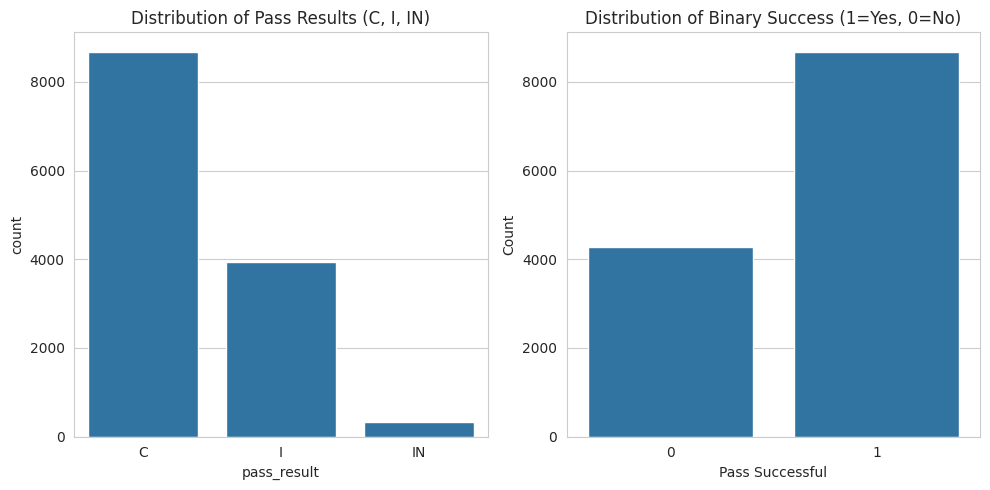

Overall Pass Success Rate: 66.99%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualizing the Dependent Variable (Pass Success)
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=master_df, x='pass_result')
plt.title('Distribution of Pass Results (C, I, IN)')

plt.subplot(1, 2, 2)
sns.countplot(data=master_df, x='is_successful_pass')
plt.title('Distribution of Binary Success (1=Yes, 0=No)')
plt.xlabel("Pass Successful")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Get the exact percentage
success_rate = master_df['is_successful_pass'].mean()
print(f"Overall Pass Success Rate: {success_rate:.2%}")

**Data Type:** Categorical  
**Units:** C (Complete), I (Incomplete), IN (Intercepted)  
**Representation:** The pass result of a play  
**Transformations Required?** Yes, there was transformation required. We transformed a C pass to 1 meaning successful pass and all other values to 0 meaning unsucessful pass.  
**Missing Data/Outliers:** None  
**Distribution:** In buckets and there's a significant majority of Completed Passes with an overall of 66.99%

In [ ]:
master_df['pass_result'].describe()

,pass_result
count,12965
unique,3
top,C
freq,8685


In [ ]:
master_df['pass_result'].value_counts()

,count
pass_result,
C,8685
I,3945
IN,335


### b) `receiver_speed`

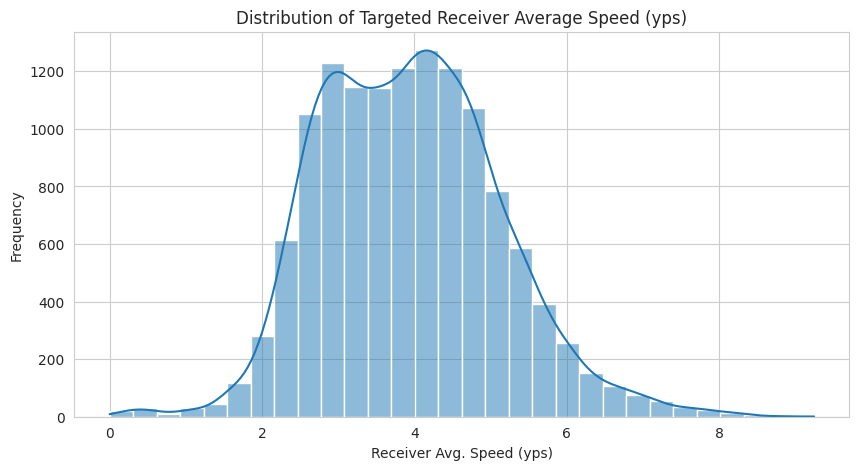

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(master_df['receiver_avg_speed'], bins=30, kde=True)
plt.title('Distribution of Targeted Receiver Average Speed (yps)')
plt.xlabel('Receiver Avg. Speed (yps)')
plt.ylabel('Frequency')
plt.show()

**Data Type:** Numerical  
**Units:** yards per second   
**Representation:** The average speed of the receiver  
**Transformations Required?** None   
**Missing Data:** None (Derived Parameter)  
**Distribution:** Has an almost normal distribution with an average of 4 yps

In [ ]:
z_scores_rspeed = np.abs(stats.zscore(master_df['receiver_avg_speed']))
outliers_rspeed = np.where(z_scores_rspeed > 3)
print(f"Number of receiver speed outliers (Z > 3): {len(outliers_rspeed[0])}")

Number of receiver speed outliers (Z > 3): 97


I wouldn't consider these as outliers. Same as said in the previous phase, these are expected outliers since they are real data, players while playin in intense matches, often tend to push their limits and strength. The max is 9.245 yps and according to few internet resources, the elite atheletes run at about 9.7 yps.

In [ ]:
master_df['receiver_avg_speed'].describe()

,receiver_avg_speed
count,12965.000000
mean,3.936628
std,1.181408
min,0.000000
25%,3.038519
50%,3.907742
75%,4.703158
max,9.245556


### c) `offense_formation`

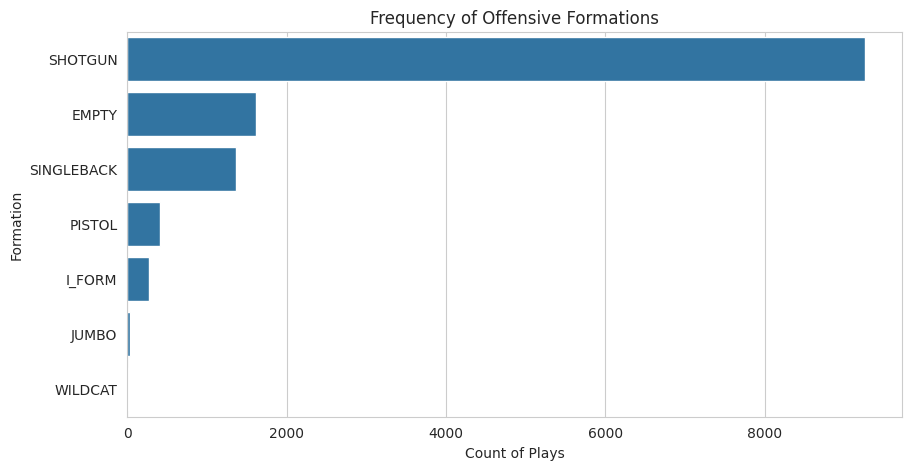

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=master_df, y='offense_formation', order=master_df['offense_formation'].value_counts().index)
plt.title('Frequency of Offensive Formations')
plt.xlabel('Count of Plays')
plt.ylabel('Formation')
plt.show()

**Data Type:** Categorical  
**Units:** SHOTGUN, EMPTY, SINGLEBACK, PISTOL, I_FORM, JUMBO, WILDCAT   
**Representation:** The formation used by the offensive team  
**Transformations Required?** None   
**Missing Data/Outliers:** None  
**Distribution:** In buckets and there's a significant majority formation that offensive teams often choose - SHOTGUN

In [ ]:
master_df['offense_formation'].describe()

,offense_formation
count,12965
unique,7
top,SHOTGUN
freq,9265


In [ ]:
master_df['offense_formation'].value_counts()

,count
offense_formation,
SHOTGUN,9265
EMPTY,1616
SINGLEBACK,1365
PISTOL,414
I_FORM,274
JUMBO,28
WILDCAT,3


### d) `defenders_in_the_box`

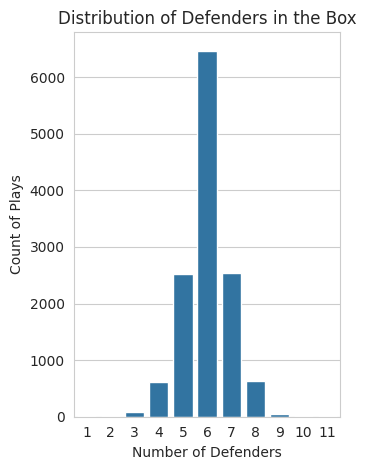

In [ ]:
plt.subplot(1, 2, 2)
sns.countplot(data=master_df, x='defenders_in_the_box')
plt.title('Distribution of Defenders in the Box')
plt.xlabel('Number of Defenders')
plt.ylabel('Count of Plays')

plt.tight_layout()
plt.show()

**Data Type:** Numerical  
**Units:** Individuals/Person  
**Representation:** The number of defenders used by the offensive team at the Line of Scrimmage  
**Transformations Required?** None   
**Missing Data/Outliers:** None  
**Distribution:** A normal distribution of an average of 6 defenders at the line

In [ ]:
z_scores_def = np.abs(stats.zscore(master_df['defenders_in_the_box']))
outliers_def = np.where(z_scores_def > 3)
print(f"Number of defenders in the box outliers (Z > 3): {len(outliers_def[0])}")

Number of defenders in the box outliers (Z > 3): 180


Again, I wouldn't call these outliers as these are formations in the game as certain formations would need more or lesser defenders on the line and since majority of the data lies between 5-7, anything beyond 4 or 8 looks like an outlier but in the real world, having 3 or lesser defender or 9 or more defenders correspond to certain formations, thus explaining the outliers.

In [ ]:
master_df['defenders_in_the_box'].describe()

,defenders_in_the_box
count,12965.000000
mean,5.997840
std,0.968413
min,1.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,11.000000


In [ ]:
master_df['defenders_in_the_box'].value_counts()

,count
defenders_in_the_box,
6,6469
7,2535
5,2526
8,638
4,617
3,85
9,49
10,16
2,15


### e) `pass_length`

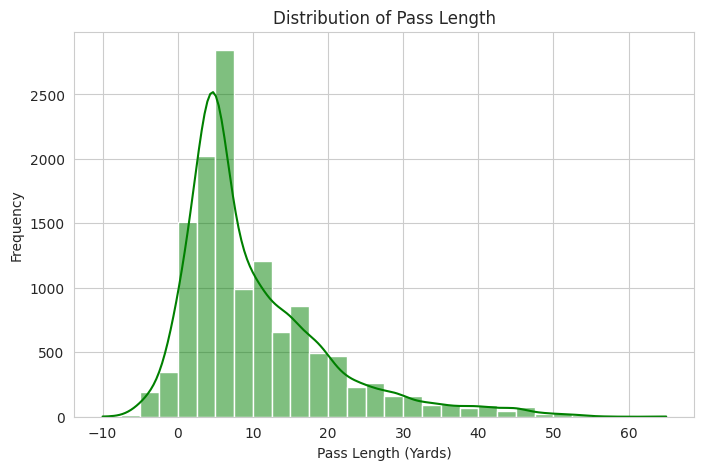

count    12965.000000
mean        10.084073
std          9.743305
min        -10.000000
25%          4.000000
50%          7.000000
75%         14.000000
max         65.000000
Name: pass_length, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(master_df['pass_length'], bins=30, kde=True, color='green')
plt.title('Distribution of Pass Length')
plt.xlabel('Pass Length (Yards)')
plt.ylabel('Frequency')
plt.show()

print(master_df['pass_length'].describe())

**Data Type:** Numerical  
**Units:** yards  
**Representation:** The length of a pass (complete, incomplete, intercepted)  
**Transformations Required?** None   
**Missing Data/Outliers:** None  
**Distribution:** A positive skewed distribution with an average of about 10 yards but highest frequency around 5 yards

In [ ]:
z_scores_plen = np.abs(stats.zscore(master_df['pass_length']))
outliers_plen = np.where(z_scores_plen > 3)
print(f"Number of pass length value outliers (Z > 3): {len(outliers_plen[0])}")

Number of pass length value outliers (Z > 3): 278


Again these wouldn't be outliers, since we have to consider the fact that there are incomplete passes which are present in the data too. So a player could've thrown a mighty 65 yard pass but nobody received it. Such throws with 35+ ish yards would usually be an incomplete pass. However, a pass length with negative value means that the pass went behind/ backwards and this is usually a completed pass.

In [ ]:
master_df['pass_length'].describe()

,pass_length
count,12965.000000
mean,10.084073
std,9.743305
min,-10.000000
25%,4.000000
50%,7.000000
75%,14.000000
max,65.000000


In [ ]:
master_df['pass_length'].value_counts()

,count
pass_length,
5,1236
4,1128
6,971
3,891
2,646
...,...
55,1
-8,1
57,1


## **5. RELATIONSHIP BETWEEN VARIABLES**
****

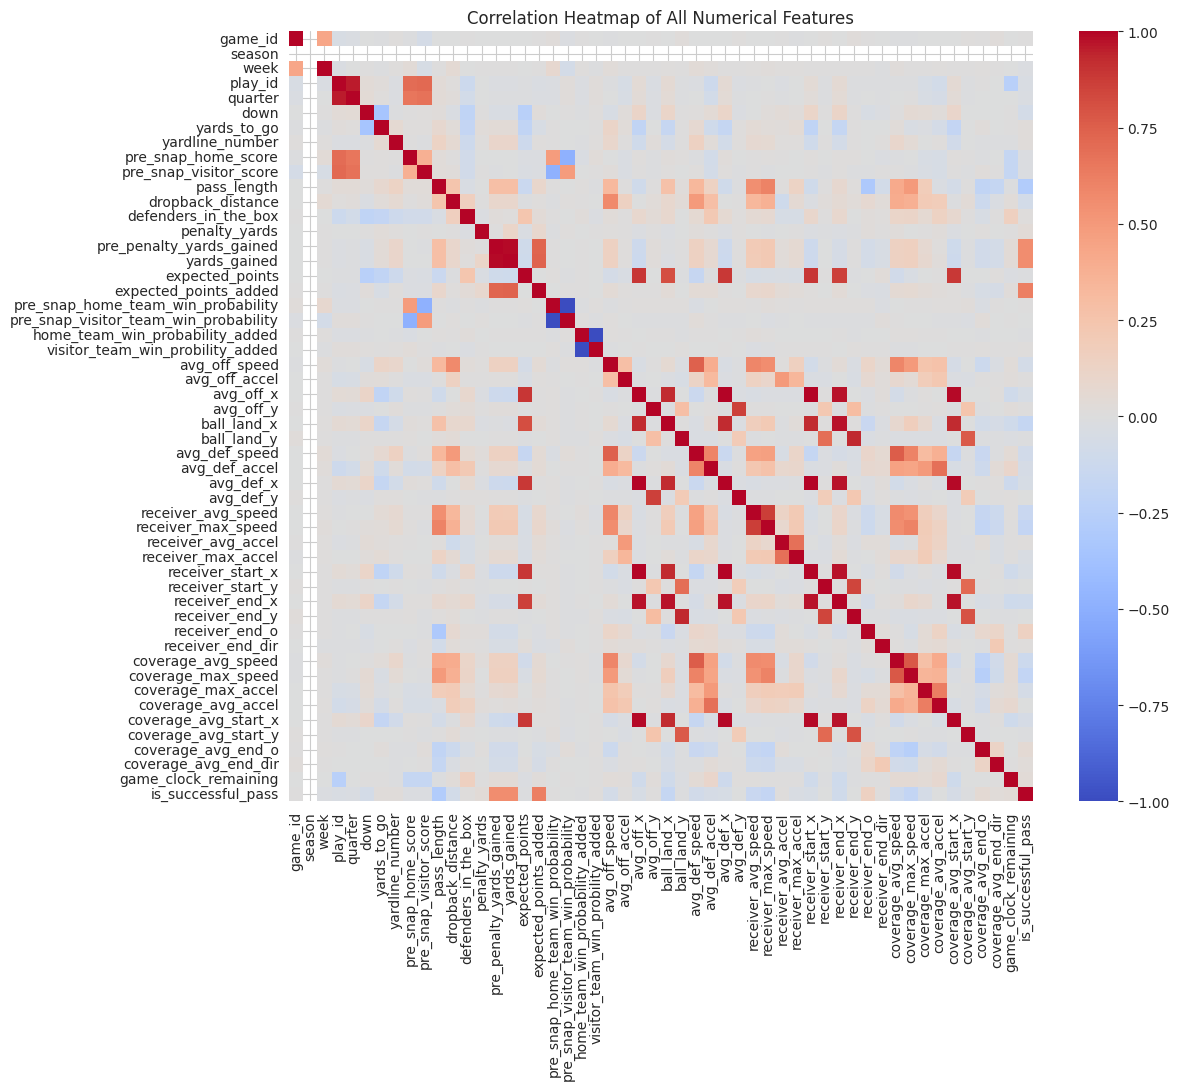


--- Top Correlations with 'is_successful_pass' ---
is_successful_pass          1.000000
expected_points_added       0.621870
pre_penalty_yards_gained    0.556684
yards_gained                0.556120
receiver_end_o              0.148141
coverage_avg_end_o          0.047192
penalty_yards               0.038457
game_clock_remaining        0.034942
coverage_avg_end_dir        0.030295
yardline_number             0.022386
Name: is_successful_pass, dtype: float64

--- Bottom Correlations with 'is_successful_pass' ---
pass_length          -0.285754
coverage_max_speed   -0.181733
receiver_max_speed   -0.173626
ball_land_x          -0.166956
receiver_avg_speed   -0.148299
coverage_avg_speed   -0.119754
receiver_end_x       -0.099471
avg_def_speed        -0.089024
dropback_distance    -0.078972
avg_off_speed        -0.074372
Name: is_successful_pass, dtype: float64


In [ ]:
plt.figure(figsize=(12, 10))

numeric_cols = master_df.select_dtypes(include=np.number) # Select only the numeric columns for correlation

corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, center=0)
plt.title('Correlation Heatmap of All Numerical Features')
plt.show()

print("\n--- Top Correlations with 'is_successful_pass' ---")
print(corr_matrix['is_successful_pass'].sort_values(ascending=False).head(10))
print("\n--- Bottom Correlations with 'is_successful_pass' ---")
print(corr_matrix['is_successful_pass'].sort_values(ascending=True).head(10))

The correlation heatmap gives us our first numerical look at relationships. The heatmap is fascinating and directly challenges one of my assumptions.

There are some obvious strong correlations between `is_successful_pass` and `expected_points_added`, `pre_penalty_yards_gained` and `yards_gained` since these variables directly correlate to a successful pass. These are not what I'm worried about though.

1. `pass_length` (-0.28): This is the strongest correlation by far. It's a strong negative correlation, which now makes sense: the longer the pass, the less likely it is to be successful.

2. `receiver_end_o` (0.14): This is another correlation to look at. Since we've transformed all the plays to go right, the greater the angle the better the success rate of the pass. It means if the orientation is around 360, the player is facing the ball so he can catch the ball better as he can track it easily, if the orientation is around 20 or so, it means the player is facing away from the ball and he can't track the ball so lesser chances of a succesful pass.

3. `receiver_max_speed` (-0.17): This is the most surprising finding. There is a negative correlation between the receiver's max speed and success. This contradicts my initial hypothesis... but it makes sense. A receiver running a short 5-yard route (which has a very high-success-rate pass) will have a low max speed. A receiver running a 40-yard route (which has a low-success-rate pass) will have a high max speed. This shows that pass_length is a confounding variable. We need to dig deeper.

3. `coverage_max_speed` (-0.18): This supports our hypothesis. Higher max speed from the defense is negatively correlated with pass success as they can intercept the pass or tackle the offender from catching the ball.

4. `penalty_yards` (0.03): This is a positive correlation. This is likely due to "Pass Interference" penalties, which are counted as a successful offensive play in many analyses (they result in a first down).

5. `game_clock_remaining` (0.03): This is something I wanted to look at and it does effect the rate of success. The greater the game time remaining on the clock, the better the success rate as there's no pressure on the offense to make the pass and vice-versa.

Some other correlations to observe are :  
1. `home_team_win_probability_added` and `visitor_team_win_probability_added` are heavily negatively correlated. This because of obvious reasons that if one team's probability increases the other team's probability decreases and vice-versa.  

2. `down` and `yards_to_go` are negatively correlated. This is because, a team has 4 downs to cross a particular line, the greater the `down` the closer they are to the line they should cross hence lesser the `yards_to_go`. This is what occurs in general but there are cases when it can be other wise too, when the defense is too good and they push the offense back, they may have to cross a large distance to reach the line in their 4th down. Thus you don't see a strong negative correlation but a mild negative correlation.

### SPEED V. PASS SUCCESS

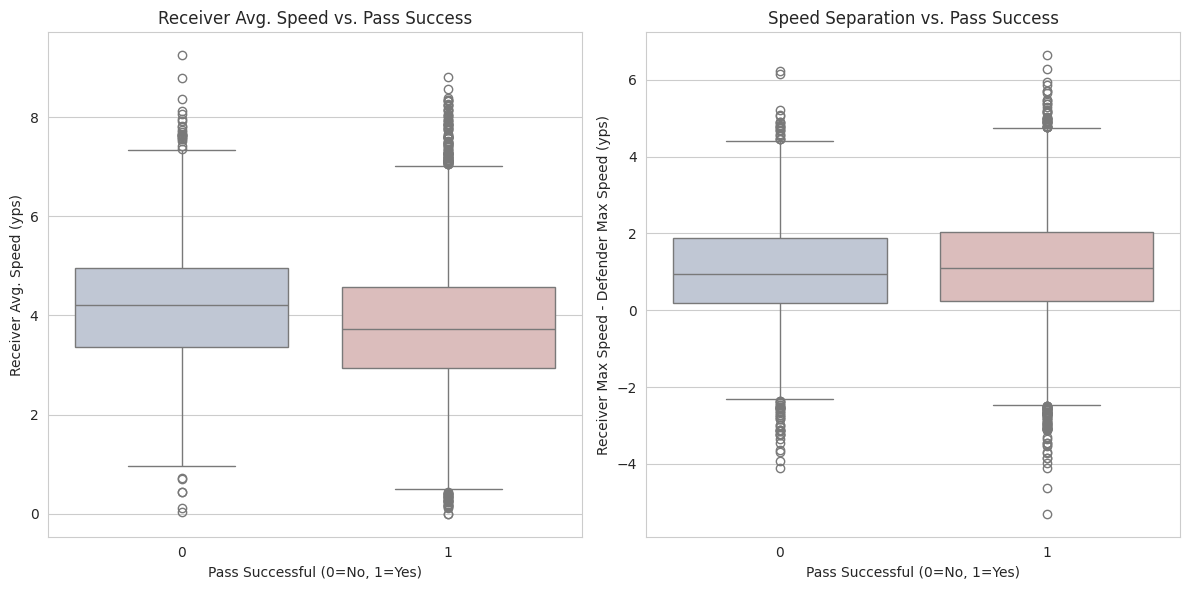

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=master_df, x='is_successful_pass', y='receiver_avg_speed', palette="vlag")
plt.title('Receiver Avg. Speed vs. Pass Success')
plt.xlabel('Pass Successful (0=No, 1=Yes)')
plt.ylabel('Receiver Avg. Speed (yps)')

master_df['speed_separation'] = master_df['receiver_max_speed'] - master_df['coverage_max_speed']

plt.subplot(1, 2, 2)
sns.boxplot(data=master_df, x='is_successful_pass', y='speed_separation', palette="vlag")
plt.title('Speed Separation vs. Pass Success')
plt.xlabel('Pass Successful (0=No, 1=Yes)')
plt.ylabel('Receiver Max Speed - Defender Max Speed (yps)')

plt.tight_layout()
plt.show()

**Left Plot:**  
This is what left me confused. A lower average speed of the defender is implying a successful pass. But I realized that is the case because, if there exists a higher average speed then it means the receiver is going far i.e., gaining more distance (yards) and we saw that higher yards pass are less successful. So the `pass_length` is a confounding variable that I hadn't thought of.

**Right Plot:**  
Although not much difference, it conveys the difference in speed between the main defender and the main receiver. I can see a small difference in the 2 box plots conveying that if there's a slightly higher difference between the 2 speeds, there's a better shot at the pass being successful which makes sense. If the receiver is quicker than the defender, he gets to the ball early and has more time to catch the ball before the defender can get to him.

### OFFENSE FORMATION V. PASS SUCCESS

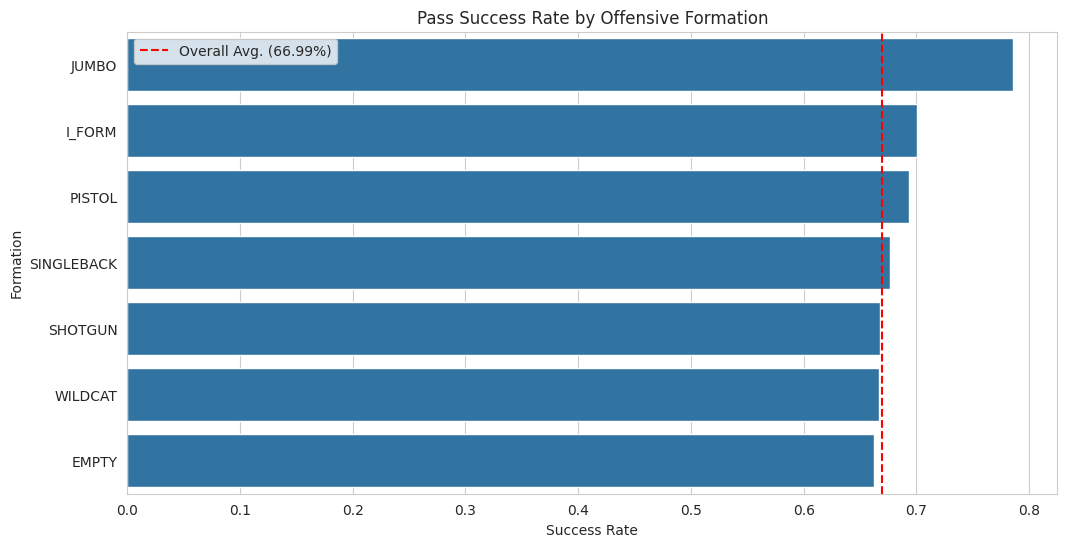

In [ ]:
plt.figure(figsize=(12, 6))

# Calculate success rate for each formation
formation_success = master_df.groupby('offense_formation')['is_successful_pass'].mean().sort_values(ascending=False)

# Plot the success rates
sns.barplot(x=formation_success.values, y=formation_success.index, orient='h')
plt.title('Pass Success Rate by Offensive Formation')
plt.xlabel('Success Rate')
plt.ylabel('Formation')
plt.axvline(x=success_rate, color='red', linestyle='--', label=f'Overall Avg. ({success_rate:.2%})')
plt.legend()
plt.show()

After further research into each of these formations, I came to realize that JUMBO is the formation that is used when the offense team needs just 1-2 yards to reach the end-zone(for a touchdown) and since this is relatively easier to do, it has a higher success rate. But as seen before this is the least used formation because a situation where the offense team needs just 1-2 yards to the end-zone is relatively less. SHOTGUN being the widely popular formation to go to has the average pass success rate.

### PLAY ACTION V. COVERAGE

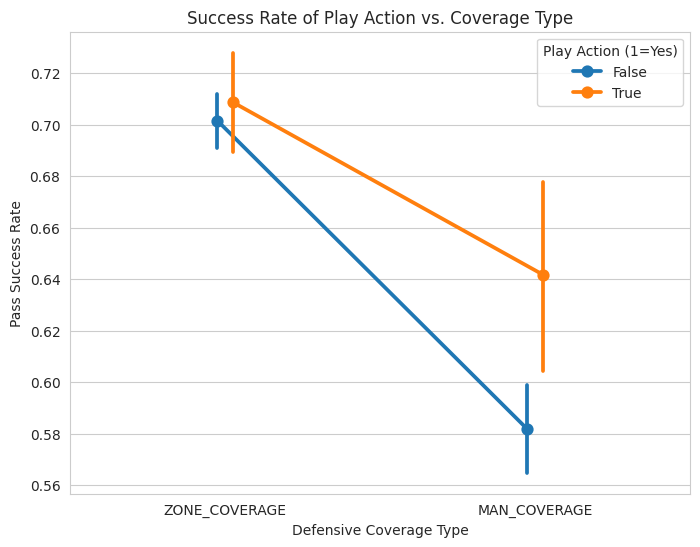

In [ ]:
plt.figure(figsize=(8, 6))
sns.pointplot(data=master_df, x='team_coverage_man_zone', y='is_successful_pass', hue='play_action', dodge=True)
plt.title('Success Rate of Play Action vs. Coverage Type')
plt.xlabel('Defensive Coverage Type')
plt.ylabel('Pass Success Rate')
plt.legend(title='Play Action (1=Yes)')
plt.show()

This is an insight into the defensive strategy. When a play_action is performed (a play-action is a pass play in football in which the quarterback fakes a handoff before passing the ball. It is faked and made to look like a running-play but it is actually a pass), there's a higher chance of getting a successful pass when the defense is using a Zone_Coverage strategy than when using a Man_Coverage strategy. This is because if the defense is marking each man, then the defender who's tagged to the offender marks them better because they know who to defend thus reducing the success of a pass. Also, in general, performing a play action yields a better success rate of the pass.

### POSITION V. PASS SUCCESS

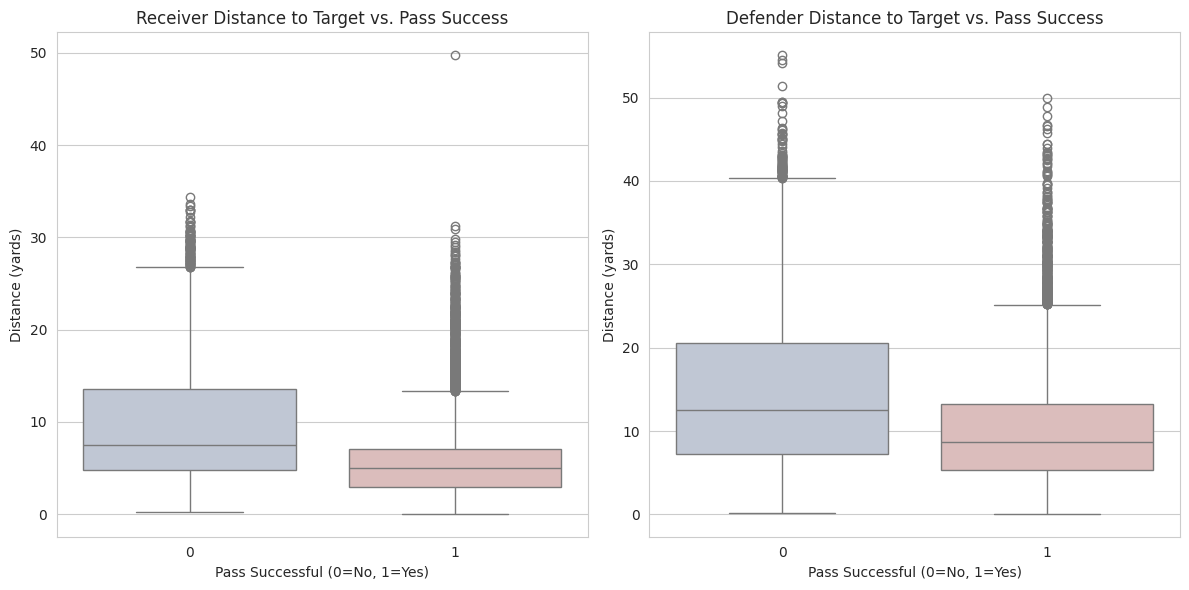

In [ ]:
# Create a "receiver_dist_to_target"
# This is the distance from the receiver's position *at pass throw* to where the ball *landed*
master_df['receiver_dist_to_target'] = np.sqrt(
    (master_df['receiver_end_x'] - master_df['ball_land_x'])**2 +
    (master_df['receiver_end_y'] - master_df['ball_land_y'])**2
)

# Create a "defender_dist_to_target"
master_df['defender_dist_to_target'] = np.sqrt(
    (master_df['coverage_avg_start_x'] - master_df['ball_land_x'])**2 +
    (master_df['coverage_avg_start_y'] - master_df['ball_land_y'])**2
)

# Plot this new feature vs. pass success
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=master_df, x='is_successful_pass', y='receiver_dist_to_target', palette="vlag")
plt.title('Receiver Distance to Target vs. Pass Success')
plt.xlabel('Pass Successful (0=No, 1=Yes)')
plt.ylabel('Distance (yards)')

plt.subplot(1, 2, 2)
sns.boxplot(data=master_df, x='is_successful_pass', y='defender_dist_to_target', palette="vlag")
plt.title('Defender Distance to Target vs. Pass Success')
plt.xlabel('Pass Successful (0=No, 1=Yes)')
plt.ylabel('Distance (yards)')

plt.tight_layout()
plt.show()

The average distance between where the ball landed and the receiver was, should be close to 0 yards and that's exactly what I'm seeing here, because if the receiver is too far from where the ball landed, then it's obvious that the pass was unsuccessful. I see similar pattern with the defender as well but he is much further away from the receiver from the ball which makes sense for a successful pass to be completed.  

However, I also see several outliers in the graph. The reason why this is because these are long range passes. The `receiver_end_x` or `receiver_end_y` is the last x and y co-ordinate of the player before the ball was thrown, and the `ball_land_x` and `ball_land_y` is the position of the ball at the end of the play. So in long range passes, the ball is thrown further from where the receiver is and thus he has to gain distance to get to the ball, so at the instant the ball was just about to be thrown, the player could be be 10, 15 or even 20 yards from the ball landing position and thus giving larger distance difference.

### GAME CLOCK  (Along with Home and Away Games indicator) v. PASS SUCCESS

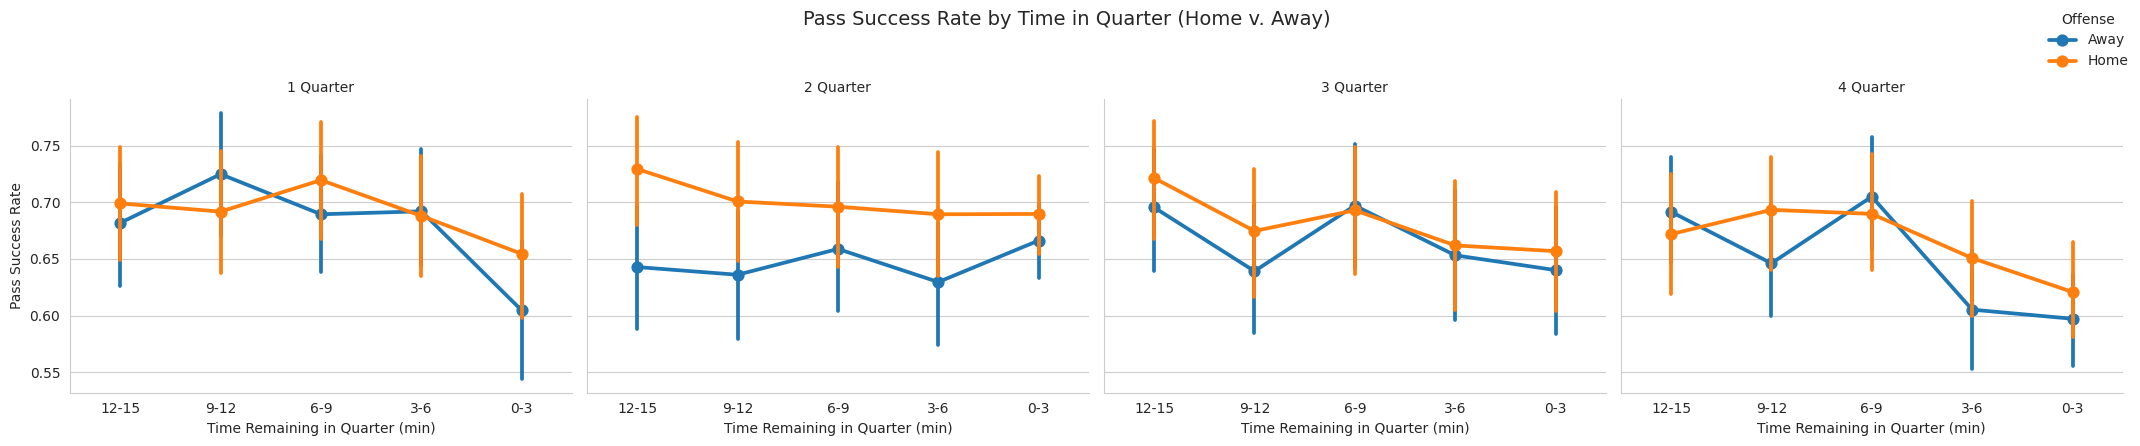

In [ ]:
# Bin the game_clock_remaining into 3 min intervals
bin_labels = ['0-3', '3-6', '6-9', '9-12', '12-15']

master_df['quarter_time_bin']=pd.cut(master_df['game_clock_remaining'], bins=[0, 180, 360, 540, 720, 900], labels=bin_labels, include_lowest=True, right=True)
master_df_4qtr=master_df[master_df['quarter'].isin([1,2,3,4])] # Limit the data to 4 quarters since we don't have enough data for the 5th quarter

# Generate plot

g=sns.catplot(
    data=master_df_4qtr,
    x='quarter_time_bin',
    y='is_successful_pass',
    hue='offense_is_home',
    col='quarter',
    kind='point',
    aspect=1.2,
    order=['12-15','9-12','6-9','3-6','0-3'],
    height=4.2,
)

g.fig.suptitle('Pass Success Rate by Time in Quarter (Home v. Away)', fontsize=14, y=1.05)
g.set_axis_labels('Time Remaining in Quarter (min)', 'Pass Success Rate')
g.set_titles(col_template="{col_name} Quarter")

g.legend.set_loc('upper right')
g.legend.set_title('Offense')
new_labels = ['Away', 'Home']
for t, l in zip(g.legend.texts, new_labels):
    t.set_text(l)

g.fig.tight_layout()
plt.show()

These plots makes it quite clear that in the dying moments of a quarter and finally the game, the home team always has an upper edge in making a successful pass. There's also a general steady decline in the success rate of the passes as the time goes down per quarter and the game as well. The one striking observation is how the rate goes higher in the last quarter with 6-9 min remaining and how the away team has a better rate than the home team.

## **6. DO YOU TRUST THE DATA**
****

Yes, I do. Much better than the previous phase. Credibility was always a Yes, but now I have much better and in-depth data got by transforming and manipulating, that I can use for better analysis.

## **7. WRAP UP**
****

To wrap up all that I've done till now:  

1. I realized that `pass_length` has an important role to play in the success of a pass and that it a confounding variable that I did not account for.  

2. The speed is negatively correlated to the success of a pass.

3. However, the speed difference between the receiver and the defender is positively correlated to the success of a pass.

4. Playing at home or away makes a difference although not too huge, it does matter to the success of a pass.

5. The orientation of the player to the ball at the time of release of the ball matters to the success of a pass.

6. SHOTGUN is the most used offensive formation with a 66.99% of success rate while JUMBO, although one of the least used, has the highest success rate.

7. the game clock plays a role in the success of a pass too indicating higher pressure at the end of the game clock thus lower success rate.

The receiver speed has slightly thrown me off by showing a negative correlation, I expected a higher receiver speed to always have a higher success rate. But I will not change my hypothesis, instead account for more factors to make a successful pass like pass length. So now my  changed hypothesis will also account for pass length along with receiver speed and orientation, formation of the offense.

I would want to explore more in pass_length and dig deeper into what range of pass length has different player orientations and speed and which of those were successful and unsuccessful.

# ***PROJECT 4***

## **1. ML TASK DEFINITION**
****

This project will be a ***classification task***. I am trying to predict a rather categorical outcome which is whether a pass will be successful (1) or not (0). Although the pass results are 3 different kinds, which are Complete, Incomplete or Intercept, I've transformed it to Complete as 1 and Incomplete or Intercept as 0.  
It will be based on ***supervised learning***. I have a labelled dataset where the transformed target variable is `is_successful_pass`.  
In the end, I intend to train a classifier model using the features I engineered in phase 3 and some more later, to predict the probability of a pass being successful.

## **2. FEATURE SELECTION AND DIMENSIONALITY REDUCTION**
****

In [ ]:
master_df.shape

(12965, 75)

In [ ]:
# COLUMNS FROM PHASE 3 THAT I WILL USE
# down, yards_to_go, quarter, offense_is_home, game_clock_remaining,
# pass_length, play_action, team_coverage_man_zone, receiver_max_speed,
# coverage_max_speed, speed_separation, dropback_distance
# receiver_dist_to_target, defender_dist_to_target

master_df['defender_separation_at_start'] = np.sqrt(
    (master_df['receiver_start_x'] - master_df['coverage_avg_start_x'])**2 +
    (master_df['receiver_start_y'] - master_df['coverage_avg_start_y'])**2
)

master_df['orientation_diff'] = abs(master_df['receiver_end_o'] - master_df['coverage_avg_end_o'])
master_df['orientation_diff'] = master_df['orientation_diff'].apply(lambda x: 360 - x if x > 180 else x)

# Map formations to estimated number of receivers
receivers_map = {
    'EMPTY': 5, 'SHOTGUN': 3, 'PISTOL': 3, 'SINGLEBACK': 3,
    'I_FORM': 2, 'JUMBO': 1, 'WILDCAT': 0
}
master_df['est_receivers'] = master_df['offense_formation'].map(receivers_map).fillna(3)

master_df['box_receiver_ratio'] = np.where(
    (master_df['defenders_in_the_box'] / (master_df['est_receivers'] + 1)) > 0,
    master_df['defenders_in_the_box'] / (master_df['est_receivers'] + 1),
    0
)

master_df['deep_shot_pressure'] = master_df['pass_length'] * (1 / (master_df['game_clock_remaining'] + 1))

# NEW COLUMNS I PLAN TO USE
# defender_seperation_at_start (distance between the receiver and average defender position),
# orientation_diff (difference between the orientation of the reciever and the defender)
# box_receiver_ratio (Ratio of Defenders in Box to Receivers)
# deep_shot_pressure (pressure indicator on the pass to make a deep pass, it's based on pass_length and game_clock_remaining)


**DIMESIONALITY REDUCTION:**  
I have cut down several useless columns while also transforming multiple columns to one column.  
My initial dataset had **75 columns**, which are now reduced to **18 columns**.  
So, now the **resulting dataset has dimensions: (12965, 18)**  

The raw data had play_id, game_id, team_names and many such unwated features for building my model. So I had to discard them.
The raw data also had tracking co-ordinates and speed values of every player, which are now limited to just the players of importance and also these data are now aggregated.

I have aggregated every player's speed and acceleration and other metrics to average aggregate and segregated them to offense and defense. While doing this I also picked up the key player from each offense and defense, which was given by the feature `player_to_predict`, and found out metrics for these players seperately.   
Finally instead of having them all of these individual metrics, I transformed them to a new feature called `speed_separation` to store the difference in speed between the receiver and the whole defense.   
Similarly, I performed transformations to obtain `orientation_diff`.  

I also created new features called `defender_seperation_at_start` which is basically giving us the distance between the receiver x/y and the average defense x/y.  

`box_receiver_ratio` was created to cutshort 2 features, which are formations and defenders_in_the_box. I created an estimate of number of receivers (players who can catch) in a particular formation and to this I'm finding the ratio of the number of defender's in the box and the number of receivers. If this value is greater implies there's more defenders than receivers in the box who are trying to stop the 'run' and in the this situation a pass would be a high success because nobody is guarding the receiver and if it was lesser, it would mean that the defenders are spread out to cover or block the pass thus reducing the success of the pass. Just passing the formation labels wouldn't ideally make sense since there's a skew in the data with majority of the data being SHOTGUN formation and minority with JUMBO and JUMBO being the most successful formation. So, I had to merge these 2 features so the model could better understand the scenarios.

`deep_shot_pressure` this is a pressure indicator feature on the pass to make a deep pass and is a transformation of pass_length and game_clock_remaining features.  

**ASSUMPTIONS:**  
I am assuming that all the plays are **Independent and Identically Distributed** for the purpose of this model, although in reality, the plays within the same game have some dependence on each other.  

I am also using `receiver_dist_to_target` feature for my model (derived from `ball_land_x/y`). Technically, this gives us the landing spot of the ball which is ideally not known until the play ends. However, for this analysis, I will be treating this variable as the **Intended Target Location**. So, my model will be calculating the conditional probability of a catch being made given the specific target location, rather than predicting the throw location itself.  

**NAME OF THE FEATURES:**  
1. down - Discrete
2. yards_to_go - Continuous
3. quarter - Discrete
4. offense_is_home - Categorical/Binary
5. game_clock_remaining - Continuous
6. pass_length - Continuous
7. play_action - Categorical/Binary
8. team_coverage_man_zone - Categorical -> One Hot Encoded
9. receiver_max_speed - Continuous
10. coverage_max_speed - Continuous
11. speed_separation - Continuous
12. dropback_distance - Continuous
13. receiver_dist_to_target - Continuous
14. defender_dist_to_target - Continuous
15. defender_seperation_at_start - Continuous
16. orientation_diff - Continuous
17. box_receiver_ratio - Continuous
18. deep_shot_pressure - Continuous


## **3. ML ALGORITHM**
****

I will be using **Random Forest Classifer** model.  

Assumptions that this model would make are:  
Since it's a non-parametric algorithm, It does not assume that the data follows a specific distribution like Normal or Gaussian, which is why it would be a good fit for our data since speed and distance features are skewed.  
It generally requires a decently large dataset to perform well which in my case works well.

Known Issues and Mitigation:  
Overfitting - which is highly possible if the individual trees in the forest are allowed to grow too deep or if the dataset is too noisy (which is highly likely given that this is real world data).
How to mitigate this issue? By tuning max_depth and the minimum samples leaf and other parameters.  

Why is this a good model for my task?  
Random Forest captures non-linear data. As we saw in the phase 3 of the project, there were certain features which had complex relations. Ex: the `play_action` worked well specifically against 'Zone' coverage but not much against 'Man' coverage. So Random Forest can understand/learn these interactions unlike other linear models.  
It is robust to noisy data and also handles mixed data types as the data has continous variables, binary and one-hot encoded variables without requiring feature scaling.

## **4. HYPERPARAMETERS**
****

For the Random Forest Classifier model, I have chosen some parameters to be picked from a couple of values. I want the model to try different combinations of these parameters and provide the best model from these combinations.  
1. `n_estimators`: [200, 250, 300] - Controls the number of trees in the Random Forest. Generally, more trees imply better stability of model and reduces variance.
2. `max_depth`: [4, 6, 8] - This limits the maximum depth of each tree thus preventing the model from overfitting.
3. `min_samples_split`: [3, 5, 10] - This sets the minimum number of samples required to split an internal node. So higher values prevent the tree from creating very specific branches.
4. `min_samples_leaf`: [3, 4, 8] - This guarantees that every leaf node has at least these many samples making sure that prediction is not made based of a single data point or row.
5. `max_features`: ['sqrt', 'log2', None] - This determines how many features each tree considers when looking for the best split. Limiting this forces the tree to be difference from each other which makes the overall 'vote' of the forest to be more robust or unique.


## **5. POST PROCESSING TECHNIQUES**
****

No Post Processing Techniques to use for now. This is a raw binary prediction and that is sufficient to evaluate the accuracy and test the hypothesis. No threshold tuning or probability calibration is required for now.

## **6. RUN ML MODEL**
****

In [ ]:
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

feature_cols = [
    'down', 'yards_to_go', 'quarter', 'offense_is_home', 'game_clock_remaining',
    'pass_length', 'play_action',
    'box_receiver_ratio','team_coverage_man_zone',
    'receiver_max_speed', 'coverage_max_speed',
    'speed_separation', 'dropback_distance',
    'defender_separation_at_start',
    'orientation_diff', 'receiver_dist_to_target', 'defender_dist_to_target',
    'deep_shot_pressure'
                ]

target_col = 'is_successful_pass'

X = master_df[feature_cols].copy()
y = master_df[target_col].copy()

categorical_col = ['team_coverage_man_zone']
X = pd.get_dummies(X, columns=categorical_col, drop_first=True)

print("Total input features: ", X.shape[1])
print("Total input rows: ", X.shape[0])

# We will split the data by grouping particular games, so the model can learn from some games and try to predict games which are completely new
splitter = GroupShuffleSplit(test_size=.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=master_df['game_id']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# parameter distributions
param_dist = {
    'n_estimators': [200, 250, 300],
    'max_depth': [4, 6, 8],
    'min_samples_split': [3, 5, 10],
    'min_samples_leaf': [3, 4, 8],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Model Building...")
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# best model storing
best_model = random_search.best_estimator_

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy:     {test_accuracy:.2%}")
print(f"Gap (Train-Test):  {train_accuracy - test_accuracy:.2%}")


Total input features:  18
Total input rows:  12965
Train size: 10299
Test size: 2666
Model Building...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hyperparameters: {'n_estimators': 250, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 8}
Training Accuracy: 77.05%
Test Accuracy:     72.51%
Gap (Train-Test):  4.54%


***The Random Forest model achieved an accuracy of 72.51%.***

# ***PROJECT 5***

## **1. MODEL EVALUATION**
****

For a binary classification task like this, accuracy, precision, recall, F1-score and the confusion matrix would be the most informative metrics. Now, accuracy summarizes overall correctness, while the precision and recall for the *successfull pass* class captures how well the model identifies complete passes and incomplete passes, and these directly reflect real football trade-offs between taking risks and avoiding wasted downs. On the other hand, the confusion matrix provides a clear view of true and false positives and negatives, making it easier to interpret performances for team coaches and analysts.

In [ ]:
# Implementing Logistic Regression to obtain a baseline comparison for the RF model built above

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

log_reg = LogisticRegression(
    max_iter=500,
    solver="lbfgs",
    n_jobs=-1
)
log_reg.fit(X_train, y_train)

def compute_metrics(model, X_tr, y_tr, X_te, y_te, positive_label=1):
    y_tr_pred = model.predict(X_tr)
    y_te_pred = model.predict(X_te)

    metrics = {
        "train": {
            "accuracy": accuracy_score(y_tr, y_tr_pred),
            "precision": precision_score(y_tr, y_tr_pred, pos_label=positive_label),
            "recall": recall_score(y_tr, y_tr_pred, pos_label=positive_label),
            "f1": f1_score(y_tr, y_tr_pred, pos_label=positive_label),
        },
        "test": {
            "accuracy": accuracy_score(y_te, y_te_pred),
            "precision": precision_score(y_te, y_te_pred, pos_label=positive_label),
            "recall": recall_score(y_te, y_te_pred, pos_label=positive_label),
            "f1": f1_score(y_te, y_te_pred, pos_label=positive_label),
        }
    }
    return metrics, y_tr_pred, y_te_pred

rf_metrics, rf_y_train_pred, rf_y_test_pred = compute_metrics(best_model, X_train, y_train, X_test, y_test)
lr_metrics, lr_y_train_pred, lr_y_test_pred = compute_metrics(log_reg, X_train, y_train, X_test, y_test)

print("Random Forest Metrics:")
print(rf_metrics)

print("\nLogistic Regression Metrics:")
print(lr_metrics)

Random Forest Metrics:
{'train': {'accuracy': 0.7704631517623071, 'precision': 0.7643845170289434, 'recall': 0.951251265731231, 'f1': 0.8476411446249034}, 'test': {'accuracy': 0.7250562640660165, 'precision': 0.7347492092182558, 'recall': 0.917607223476298, 'f1': 0.816060225846926}}

Logistic Regression Metrics:
{'train': {'accuracy': 0.718127973589669, 'precision': 0.7261448229190165, 'recall': 0.9312888760306669, 'f1': 0.8160212941251029}, 'test': {'accuracy': 0.7134283570892723, 'precision': 0.7210526315789474, 'recall': 0.927765237020316, 'f1': 0.8114511352418559}}


In [ ]:
# Organizing the metrics into a dataframe for easier comparison on successful passes only

def metrics_to_df(rf_m, lr_m):
    rows = []
    for split in ["train", "test"]:
        rows.append({
            "Model": "Random Forest",
            "Split": split.capitalize(),
            "Accuracy": rf_m[split]["accuracy"],
            "Precision (class=1)": rf_m[split]["precision"],
            "Recall (class=1)": rf_m[split]["recall"],
            "F1 (class=1)": rf_m[split]["f1"],
        })
        rows.append({
            "Model": "Logistic Regression",
            "Split": split.capitalize(),
            "Accuracy": lr_m[split]["accuracy"],
            "Precision (class=1)": lr_m[split]["precision"],
            "Recall (class=1)": lr_m[split]["recall"],
            "F1 (class=1)": lr_m[split]["f1"],
        })
    return pd.DataFrame(rows)

metrics_df = metrics_to_df(rf_metrics, lr_metrics)
metrics_df

,Model,Split,Accuracy,Precision (class=1),Recall (class=1),F1 (class=1)
0,Random Forest,Train,0.770463,0.764385,0.951251,0.847641
1,Logistic Regression,Train,0.718128,0.726145,0.931289,0.816021
2,Random Forest,Test,0.725056,0.734749,0.917607,0.816060
3,Logistic Regression,Test,0.713428,0.721053,0.927765,0.811451


The Random Forest model and Logistic Regression model were both trained on the same features and train/test data split to allow a fair comparison of the performance metrics. The metrics table shows us that the Random Forest model attains a higher test accuracy and slightly better F1-score for predicting successful passes than the Logistic Regression model. This suggests that the Random Forest model is capturing important non-linear relationships between the features involved in building the model, which the Logistic Regression model isn't able to.

I had to compare the metrics across models. Logistic Regression provides a useful baseline and is more interpretable in terms of linear effects, but it's lower test performance indicates that the underlying relationships in NFL passing plays are not purely linear. Given that I had to model complex spatial and contextual feature interactions, Random Forest is thus proved to be the more appropriate model for this analysis.

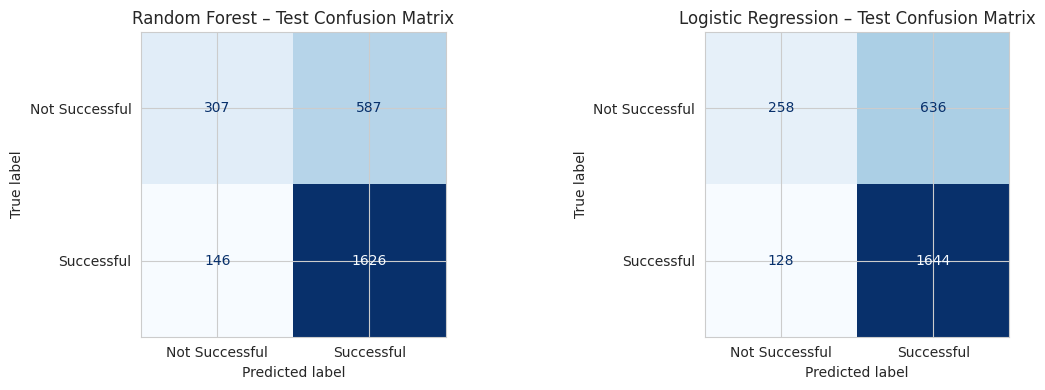

In [ ]:
# Confusion Matrices for both the models

def plot_confusion_matrices(y_true, y_pred_dict, labels=("Not Successful", "Successful")):
    fig, axes = plt.subplots(1, len(y_pred_dict), figsize=(12, 4))
    if len(y_pred_dict) == 1:
        axes = [axes]

    for ax, (name, y_pred) in zip(axes, y_pred_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
        ax.set_title(f"{name} – Test Confusion Matrix")
    plt.tight_layout()

plot_confusion_matrices(
    y_test,
    {
        "Random Forest": rf_y_test_pred,
        "Logistic Regression": lr_y_test_pred
    }
)

Now, this is a tricky spot. Although the numbers seem to make Logistic Regression more favorable, we have to observe the number of Unsuccesful passes that were predicted as Successful (False Positives) is higher in the Logistic Regression model and the number of Unsuccesful passes that were actually predicted to be Unsucessful (True Negatives) is lesser in the Logistic Regression model. This is something that matters a lot in real world sports situations and could potentially cost more damage and time. Thus, it again solidifies our selection of the Random Forest model for this analysis.

Looking at the training accuracy, it does seem like Random Forest is slightly overfitting when compared to Logistic Regression however when you look at the difference between training and testing accuracy, it's not extreme. Both models achieve good accuracies relative to their own levels, but Random Forest is clearly better in majority metrics thus suggesting a good overall fit to the problem or hypothesis.

### EXPLORING OTHER MODELS OR TWEAKS TO CHECK FOR BETTER ACCURACIES AND METRICS

#### GRADIENT BOOSTING (NEW MODEL)

In [ ]:
# Gradient Boosting algorithm

from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

gb_clf.fit(X_train, y_train)

gb_metrics, gb_y_train_pred, gb_y_test_pred = compute_metrics(
    gb_clf, X_train, y_train, X_test, y_test
)

gb_metrics

{'train': {'accuracy': 0.8518302747839596,
  'precision': 0.8272384886405054,
  'recall': 0.9849558802256618,
  'f1': 0.8992340200739567},
 'test': {'accuracy': 0.718304576144036,
  'precision': 0.7371110078959592,
  'recall': 0.8955981941309256,
  'f1': 0.8086624203821656}}

#### TWEAK TO RANDOM FOREST (GIVING BALANCED WEIGHTS TO BOTH CLASSES AND ADDING REGULARIZATION)

In [ ]:
# parameter distributions with stronger regularization

param_dist = {
    'n_estimators': [150, 200, 250, 300],
    'max_depth': [5, 7, 10],  # Reduced for stricter regularization
    'min_samples_split': [8, 12, 15],  # NEW: Higher min samples = stronger regularization
    'min_samples_leaf': [4, 6, 8],  # NEW: Higher min samples per leaf
    'max_features': ['sqrt', 'log2', None],  # Limit features per split
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced') # NEW: Introduced class_weights='balanced'

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Model Building with Regularization...")
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print("Best Hyperparameters:", best_params)

# best model storing
best_model_cw = random_search.best_estimator_

# Predictions
y_train_pred = best_model_cw.predict(X_train)
y_test_pred = best_model_cw.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

rf_cw_metrics, rf_cw_y_train_pred, rf_cw_y_test_pred = compute_metrics(best_model_cw, X_train, y_train, X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Test Accuracy: {test_accuracy:.2%}")
print(f"Regularization Gap (Train - Test): {(train_accuracy - test_accuracy):.2%}")

Model Building with Regularization...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hyperparameters: {'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10}
Training Accuracy: 84.45%
Test Accuracy: 69.99%
Regularization Gap (Train - Test): 14.45%


In [ ]:
# Extending the metrics table for comparison among all models and tweaks for successful passes only

def metrics_to_df_all_with_tweak(rf_m, rf_cw_m, lr_m, gb_m):
    rows = []
    for split in ["train", "test"]:
        rows += [
            {
                "Model": "Random Forest (base)",
                "Split": split.capitalize(),
                "Accuracy": rf_m[split]["accuracy"],
                "Precision (1)": rf_m[split]["precision"],
                "Recall (1)": rf_m[split]["recall"],
                "F1 (1)": rf_m[split]["f1"],
            },
            {
                "Model": "Random Forest (class_weight=balanced)",
                "Split": split.capitalize(),
                "Accuracy": rf_cw_m[split]["accuracy"],
                "Precision (1)": rf_cw_m[split]["precision"],
                "Recall (1)": rf_cw_m[split]["recall"],
                "F1 (1)": rf_cw_m[split]["f1"],
            },
            {
                "Model": "Logistic Regression",
                "Split": split.capitalize(),
                "Accuracy": lr_m[split]["accuracy"],
                "Precision (1)": lr_m[split]["precision"],
                "Recall (1)": lr_m[split]["recall"],
                "F1 (1)": lr_m[split]["f1"],
            },
            {
                "Model": "Gradient Boosting",
                "Split": split.capitalize(),
                "Accuracy": gb_m[split]["accuracy"],
                "Precision (1)": gb_m[split]["precision"],
                "Recall (1)": gb_m[split]["recall"],
                "F1 (1)": gb_m[split]["f1"],
            },
        ]
    return pd.DataFrame(rows)

metrics_df_all_tweaks = metrics_to_df_all_with_tweak(
    rf_metrics, rf_cw_metrics, lr_metrics, gb_metrics
)
metrics_df_all_tweaks

,Model,Split,Accuracy,Precision (1),Recall (1),F1 (1)
0,Random Forest (base),Train,0.770463,0.764385,0.951251,0.847641
1,Random Forest (class_weight=balanced),Train,0.844451,0.876506,0.894257,0.885293
2,Logistic Regression,Train,0.718128,0.726145,0.931289,0.816021
3,Gradient Boosting,Train,0.851830,0.827238,0.984956,0.899234
4,Random Forest (base),Test,0.725056,0.734749,0.917607,0.816060
5,Random Forest (class_weight=balanced),Test,0.699925,0.763844,0.794018,0.778639
6,Logistic Regression,Test,0.713428,0.721053,0.927765,0.811451
7,Gradient Boosting,Test,0.718305,0.737111,0.895598,0.808662


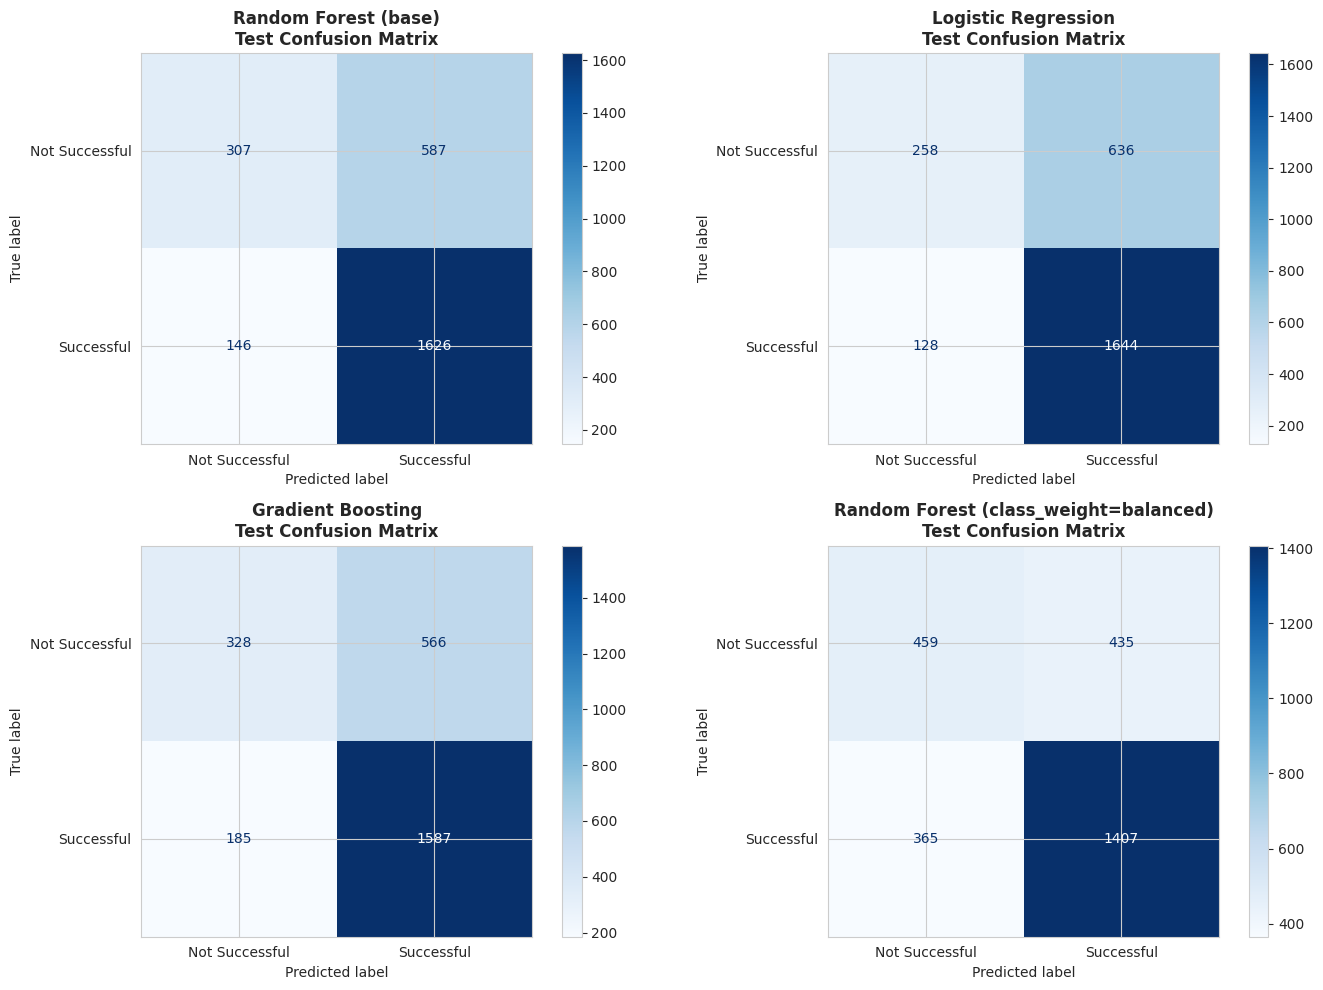

In [ ]:
# Confusion Matrices for all 4 models/tweaks - displayed in 2x2 grid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_dict = {
    "Random Forest (base)": rf_y_test_pred,
    "Logistic Regression": lr_y_test_pred,
    "Gradient Boosting": gb_y_test_pred,
    "Random Forest (class_weight=balanced)": rf_cw_y_test_pred
}

for idx, (name, y_pred) in enumerate(models_dict.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=("Not Successful", "Successful"))
    disp.plot(ax=axes[idx], values_format="d", cmap="Blues", colorbar=True)
    axes[idx].set_title(f"{name}\nTest Confusion Matrix", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

I tried one different ML algorithm viz. Gradient Boosting and one tweak into my existing Random Forest model.  

**Reason for Gradient Boosting** - It's an ensemble algorithm that builds trees sequentially, where each new tree focuses on correcting the errors made by the previous one.  
After evaluation of metrics, I can say that Gradient Boosting turned out to be an overfitting model. Training accuracy was about 85.1% while testing accuracy was just about 71.8%. It even has a higher False Negative rate compared to the Random Forest, which could be costly. This conveys that Random Forest is better balanced and suited for modelling NFL passing prediction.  

**Reason for tweaking existing Random Forest model** - The data has an imbalance of successful passes over unsuccesful pass data/rows. Almost a 2:1 ratio. Thus, the model is almost predicting every situation as a success and getting away with it. This is why I tried to introduce `class_weights = balanced` to make sure the model understood both the classes equally and gave equal importance to both the classes and penalized more during training for misclassifying, and also introduced stronger regularization.  
Looking at the metrics, the overall precision has improved significantly but the testing accuracy has dropped. This model can predict better if a unsuccessful pass was truly an unsucessful pass but it tends to misclassify a lot. Although this could be useful on a case by case basis but for our problem, it's not. Again, this solidifies our decision to stick to Random Forest (base) as our model since it has a good balance of everything and is most suited for the problem at hand.

## **2. INSIGHTS**
****

### ***A) WHAT DID YOU FIND IN TERMS OF YOUR HYPOTHESIS?***  


The original hypothesis was that higher player speed, optimal positioning and formations significantly influence the likelihood of a successful NFL pass. The Random Forest model, with a test accuracy of 72.51% strongly supports this hypothesis.  
I found out that pass_length was a significant feature in predicting a pass which initially I had never thought of. Along with this, speed, orientation of the receiver and the defender tied to this receiver, the game time remaining were all most important features in terms of predicting the success of a pass.

### ***B) ANY PREVIOUS ASSUMPTIONS THAT YOU HAD TO ADJUST, OR PROVED WRONG?***  

The first assumption that was proved wrong was that higher player speed implied a better success rate, however it was the complete opposite. A higher player speed was tied to more imcomplete passes while lower player speed was tied to better successes.  


`ball_land_x/y` was initially assumed to be a post throw feature but I had to adjust and reinterpret this feature by calculating the distance between the receiver and the ball and shift the feature from a 'outcome-based' to a 'intent-based' feature making the model's interpretation more valid.  

I had to consider all the plays as independent of each other but in the real world this isn't the case. Each play is dependent of each other making the situation even more complex.

### ***C) IS THE PROBLEM DIFFERENT FROM WHAT YOU HAD ORIGINALLY THOUGHT?***  

No, the problem still remains the same but I would need to modify or reframe the words. I would rather reframe it as **'How do spatial, contextual and tactical factors interact to shape a successful pass in the NFL'**. Because the completion is not a direct function of player attributes but an interaction of several features that are individual and team and context based, and are also non-linear in nature.

### ***D) ANYTHING YOU WOULD DO DIFFERENTLY IF YOU WERE TO DO IT AGAIN?***  

Explore class imbalance handling earlier and try a different sampling technique to pick random samples and train the models better.  

Understand the dependence of each play on the next play and try to model this dependence too.

I would explore Geometric GNNs treating the 22 players as nodes in a graph and allow the model to understand the situation in a spatial relationship of the entire field instead of just the targeted receiver and the main defender tied to this receiver.

### ***E) ARE THERE ANY POLICY OR OTHER DECISIONS THAT COULD BE INFLUENCED BY AN ANALYSIS LIKE YOURS? WHAT ARE THEY, AND WHAT COULD BE THE WIDER EFFECTS?***  

**Talent Evaluation and Scouting** - Through the model, I would suggest NFL Managers to prioritize receivers and quarterbacks who aren't just pure speed but those who consistently operate in high-separation situations and generate good seperation between them and the defenders, even if it's a relatively slow player.  

**Game Planning** - Through the model, I could suggest high probability play designs (combination of play-action and formations) against specific defensive formations. On critical downs, prioritize play calls with higher predicted success and avoid low probability deep shots against heavy coverage etc. I could suggest the other way too for defending against such plays by adjusting coverage shells, defenders in the box etc.

### ***F) WHAT ETHICAL CONCERNS SHOULD YOU OR SOMEONE READING YOUR PROJECT CONSIDER? EX. LEGAL, PRIVACY, FAIRNESS, DATA OWNERSHIP, OR ANY OTHER CONCERN OF THIS SORT THAT MIGHT BE RELEVANT***  

In terms of legality, privacy, fairness or data ownership, this dataset was directly uploaded on Kaggle for a public data competition by the NFL Association themselves. So there's a clear definition of who owns it and all the legal bounds are covered by the NFL. **Although to access this data, you would need to take part in the competition, for which you need to create an account in Kaggle.**

However, there is one thing to keep in mind. There could be algorithmic bias. If the training data over represents certain offensive designs or defensive strategies, the model may unfairly penalize underrepresented tactics or overvalue conventional approaches.

### ***G) FINAL THOUGHTS: SUMMARIZE YOUR EXPERIENCE ACROSS ALL 5 PROJECTS. WHAT DID YOU LEARN?***  

This was a very intensive and interesting project. It was also my first ever sports analytics project. There were quite a few lessons which were reinforced from my previous work experience - a models accuracy is only half the story and analyzing the entire metrics reveals much more characteristics about the model and what's working and what's not, also that EDA is very very important and in fact the most time consuming phase and most critical phase too.  

Something new I learnt was the entirety of sports analytics itself. How every feature is connected to each other, spatial data analysis, too much noise in the real world data, assumptions on certain things matter and domain knowledge plays a significant role. Also, how some features are correlated completely opposite of what you think and some features don't have enough siginificance at all. Due to this project, I got very involved into watching NFL and learnt much more about the sport.  

Analysis takes a lot of time and effort. Especially if you trying to create something new and something of significance, you have to make sure that what you are doing is right else it could lead to potential misunderstandings.